##Step 1: Load, parse and merge data files




In [28]:
import json
import xml.etree.ElementTree as ET
import pandas as pd
import numpy as np
import re
import os

json_path = 'flickr_metadata.json'
xml_path = 'flickr_metadata.xml'
output_path = f'flickr_dataset.csv'

# Read JSON file
with open(json_path, 'r', encoding='utf-8') as f:
    data_json = json.load(f)

print("=== Head of JSON file ===")
print("Data type:", type(data_json))
print("Number of records:", len(data_json))
print("First 5 records:")
print(data_json[:5])

# Read XML file
tree = ET.parse(xml_path)
root = tree.getroot()

print("\n=== Head of XML file ===")
print("Root tag:", root.tag)
print("Number of child elements:", len(root))

print("\nFirst 5 XML elements:")
for i, child in enumerate(root[:5], start=1):
    print(f"\n--- Element {i} ---")
    for sub in child:
        print(sub.tag, ":", sub.text)

=== Head of JSON file ===
Data type: <class 'list'>
Number of records: 29440
First 5 records:
[{'PostID': 49294686561.0, 'UserID': '61614526@N08', 'secret': '6ee8e62388', 'server': 65535.0, 'title': 'Cto. España Patinaje sobre hielo 2019 (Donostia)', 'ispublic': 1.0, 'isfriend': 0.0, 'isfamily': 0.0, 'farm': 66.0, 'City': None, 'Country': None, 'Post date': '2019-12-29 19:56:19', 'Taken date': '2019-12-15 19:22:31', 'tags': 'donostiasansebastian,esp,espaã±a,paisvasco,zorroaga,españa,txuri,urdin,pais,vasco,euskadi,gipuzkoa,donostia,sansebastian,palaciodehielo,ice,canon,1dx,canon135mmf2,patinaje,hielo,skating,campeonatodeespaña2019,campeonato,competicion,txuriurdin,', 'latitude': 43.30193, 'longitude': -1.971548, 'description': None, 'min_taken_date': '2019-12-15 00:00:00'}, {'PostID': 49294882732.0, 'UserID': '61614526@N08', 'secret': '93c6e87369', 'server': 65535.0, 'title': 'Cto. España Patinaje sobre hielo 2019 (Donostia)', 'ispublic': 1.0, 'isfriend': 0.0, 'isfamily': 0.0, 'farm': 6

In [29]:
import pandas as pd
json_df = pd.DataFrame(data_json)
json_df.head()


# Parse XML file
tree = ET.parse(xml_path)
root = tree.getroot()

# Convert XML data into a list of dictionaries
xml_records = []

for child in root:
    record = {}
    for sub in child:
        record[sub.tag] = sub.text
    xml_records.append(record)

# Convert to DataFrame
xml_df = pd.DataFrame(xml_records)

print("=== XML DataFrame Summary ===")

print("Columns:")
print(xml_df.columns.tolist())
print("\nFirst 5 rows:")
print(xml_df.head())

=== XML DataFrame Summary ===
Columns:
['PostID', 'UserID', 'secret', 'server', 'title', 'ispublic', 'isfriend', 'isfamily', 'farm', 'City', 'Country', 'Post_date', 'Taken_date', 'tags', 'latitude', 'longitude', 'description', 'min_taken_date']

First 5 rows:
          PostID         UserID      secret   server                 title  \
0  51217674479.0  193105688@N08  9ba67745a2  65535.0  Malaga december 2019   
1  51217123428.0  193105688@N08  b7be4e7030  65535.0  Malaga december 2019   
2  51216200382.0  193105688@N08  ac6c4518e7  65535.0  Malaga december 2019   
3  51217123403.0  193105688@N08  93f057ffe6  65535.0  Malaga december 2019   
4  51217981710.0  193105688@N08  dcfd907550  65535.0  Malaga december 2019   

  ispublic isfriend isfamily  farm  City Country            Post_date  \
0      1.0      0.0      0.0  66.0  None    None  2021-06-01 03:43:22   
1      1.0      0.0      0.0  66.0  None    None  2021-06-01 03:43:23   
2      1.0      0.0      0.0  66.0  None    None  20

In [30]:
print("=== JSON DataFrame Info ===")
json_df.info()
print("\n=== XML DataFrame Info ===")
xml_df.info()

print("\nJSON dtypes:\n", json_df.dtypes)
print("\nXML dtypes:\n", xml_df.dtypes)

print("\nJSON missing values:\n", json_df.isnull().sum())
print("\nXML missing values:\n", xml_df.isnull().sum())

print("\nJSON head:\n", json_df.head())
print("\nXML head:\n", xml_df.head())

=== JSON DataFrame Info ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 29440 entries, 0 to 29439
Data columns (total 18 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   PostID          28979 non-null  float64
 1   UserID          28979 non-null  object 
 2   secret          28979 non-null  object 
 3   server          28979 non-null  float64
 4   title           27762 non-null  object 
 5   ispublic        28979 non-null  float64
 6   isfriend        28979 non-null  float64
 7   isfamily        28979 non-null  float64
 8   farm            28979 non-null  float64
 9   City            13988 non-null  object 
 10  Country         11851 non-null  object 
 11  Post date       29440 non-null  object 
 12  Taken date      28979 non-null  object 
 13  tags            20085 non-null  object 
 14  latitude        28979 non-null  float64
 15  longitude       28979 non-null  float64
 16  description     15791 non-null  object 
 17  min

In [31]:
# Step : Standardise column names for XML and JSON

print("Original JSON columns:")
print(json_df.columns.tolist())

print("\nOriginal XML columns:")
print(xml_df.columns.tolist())

# standardise raw column names first to reduce mismatch caused by spaces/cases
json_df.columns = [str(col).strip() for col in json_df.columns]
xml_df.columns = [str(col).strip() for col in xml_df.columns]

json_rename_map = {
    'PostID': 'Post_ID',
    'UserID': 'User_ID',
    'secret': 'Secret',
    'server': 'Server',
    'title': 'Title',
    'ispublic': 'Is_Public',
    'isfriend': 'Is_Friend',
    'isfamily': 'Is_Family',
    'farm': 'Farm',
    'City': 'City',
    'Country': 'Country',
    'Post date': 'Post_Date',
    'Post_date': 'Post_Date',
    'Post Date': 'Post_Date',
    'Taken date': 'Taken_Date',
    'Taken_date': 'Taken_Date',
    'Taken Date': 'Taken_Date',
    'tags': 'Tags',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'description': 'Description',
    'min_taken_date': 'Min_Taken_Date',
    'Min_taken_date': 'Min_Taken_Date',
    'Min Taken Date': 'Min_Taken_Date'
}

xml_rename_map = {
    'PostID': 'Post_ID',
    'UserID': 'User_ID',
    'secret': 'Secret',
    'server': 'Server',
    'title': 'Title',
    'ispublic': 'Is_Public',
    'isfriend': 'Is_Friend',
    'isfamily': 'Is_Family',
    'farm': 'Farm',
    'City': 'City',
    'Country': 'Country',
    'Post date': 'Post_Date',
    'Post_date': 'Post_Date',
    'Post Date': 'Post_Date',
    'Taken date': 'Taken_Date',
    'Taken_date': 'Taken_Date',
    'Taken Date': 'Taken_Date',
    'tags': 'Tags',
    'latitude': 'Latitude',
    'longitude': 'Longitude',
    'description': 'Description',
    'min_taken_date': 'Min_Taken_Date',
    'Min_taken_date': 'Min_Taken_Date',
    'Min Taken Date': 'Min_Taken_Date'
}

json_df = json_df.rename(columns=json_rename_map)
xml_df = xml_df.rename(columns=xml_rename_map)

print("\nRenamed JSON columns:")
print(json_df.columns.tolist())

print("\nRenamed XML columns:")
print(xml_df.columns.tolist())

print("\nColumns only in JSON after renaming:")
print(set(json_df.columns) - set(xml_df.columns))

print("\nColumns only in XML after renaming:")
print(set(xml_df.columns) - set(json_df.columns))

required_columns = [
    'Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public',
    'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date',
    'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description',
    'Min_Taken_Date'
]

print("\nMissing required columns in JSON after renaming:")
print(set(required_columns) - set(json_df.columns))

print("\nMissing required columns in XML after renaming:")
print(set(required_columns) - set(xml_df.columns))

print("\nExtra columns in JSON after renaming:")
print(set(json_df.columns) - set(required_columns))

print("\nExtra columns in XML after renaming:")
print(set(xml_df.columns) - set(required_columns))

Original JSON columns:
['PostID', 'UserID', 'secret', 'server', 'title', 'ispublic', 'isfriend', 'isfamily', 'farm', 'City', 'Country', 'Post date', 'Taken date', 'tags', 'latitude', 'longitude', 'description', 'min_taken_date']

Original XML columns:
['PostID', 'UserID', 'secret', 'server', 'title', 'ispublic', 'isfriend', 'isfamily', 'farm', 'City', 'Country', 'Post_date', 'Taken_date', 'tags', 'latitude', 'longitude', 'description', 'min_taken_date']

Renamed JSON columns:
['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']

Renamed XML columns:
['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']

Columns only in JSON after renaming:
set()

Columns only in XML after rena

In [32]:

required_columns = [
    'Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public',
    'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date',
    'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description',
    'Min_Taken_Date'
]

json_df = json_df.reindex(columns=required_columns)
xml_df = xml_df.reindex(columns=required_columns)

print("\nJSON columns after reindex:")
print(json_df.columns.tolist())

print("\nXML columns after reindex:")
print(xml_df.columns.tolist())

print("\nJSON shape after reindex:", json_df.shape)
print("XML shape after reindex:", xml_df.shape)

print("\nJSON missing columns from required_columns:")
print(set(required_columns) - set(json_df.columns))

print("\nXML missing columns from required_columns:")
print(set(required_columns) - set(xml_df.columns))


merged_df = pd.concat([json_df, xml_df], ignore_index=True)

print("\nMerged dataset shape:")
print(merged_df.shape)

print("\nMerged dataset columns:")
print(merged_df.columns.tolist())

print("\nNumber of columns in merged dataset:")
print(len(merged_df.columns))

print("\nFirst 5 rows of merged dataset:")
print(merged_df.head())


JSON columns after reindex:
['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']

XML columns after reindex:
['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']

JSON shape after reindex: (29440, 18)
XML shape after reindex: (14720, 18)

JSON missing columns from required_columns:
set()

XML missing columns from required_columns:
set()

Merged dataset shape:
(44160, 18)

Merged dataset columns:
['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']

Number of columns in merged dataset:
18

First 5 rows of merged dataset:

In [33]:
# Check duplicate Post_ID records

merged_df['Post_ID'] = pd.to_numeric(merged_df['Post_ID'], errors='coerce').astype('Int64')
merged_df = merged_df.dropna(subset=['Post_ID']).copy()

print("\nPost_ID missing values after numeric conversion:")
print(merged_df['Post_ID'].isna().sum())

print("\nNumber of duplicated Post_ID values before removing duplicates:")
print(merged_df['Post_ID'].duplicated().sum())

duplicate_rows = merged_df[merged_df['Post_ID'].duplicated(keep=False)]

print("\nSample duplicated Post_ID rows:")
print(duplicate_rows.head(20))

# Keep the most complete record for each duplicated Post_ID
merged_df['non_null_count'] = merged_df.notna().sum(axis=1)
merged_df = (
    merged_df
    .sort_values(by='non_null_count', ascending=False)
    .drop_duplicates(subset=['Post_ID'], keep='first')
    .drop(columns='non_null_count')
    .reset_index(drop=True)
)

print("\nShape after removing duplicate Post_ID records:")
print(merged_df.shape)

print("\nNumber of duplicated Post_ID values after removing duplicates:")
print(merged_df['Post_ID'].duplicated().sum())


# Standardise null values to NaN

import numpy as np
import re

null_like_values = [
    '', 'null', 'NULL', 'Null', 'None', 'none',
    'NaN', 'nan', 'NAN', 'N/A', 'n/a', 'NA', 'na'
]
merged_df = merged_df.replace(null_like_values, np.nan)


merged_df = merged_df.replace(r'^\s+$', np.nan, regex=True)

print("\nMissing values after standardising nulls:")
print(merged_df.isna().sum())


# Clean text columns using Regular Expression only

text_columns = ['Title', 'City', 'Country', 'Tags', 'Description']

def clean_text(value):
    if pd.isna(value):
        return np.nan

    value = str(value)

    value = re.sub(r'&amp;', '&', value, flags=re.IGNORECASE)
    value = re.sub(r'&lt;', ' ', value, flags=re.IGNORECASE)
    value = re.sub(r'&gt;', ' ', value, flags=re.IGNORECASE)
    value = re.sub(r'&quot;|&#34;', '"', value, flags=re.IGNORECASE)
    value = re.sub(r'&#39;|&apos;', "'", value, flags=re.IGNORECASE)
    value = re.sub(r'&nbsp;', ' ', value, flags=re.IGNORECASE)


    value = re.sub(r'<[^>]+>', ' ', value)


    value = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', ' ', value, flags=re.IGNORECASE)


    value = re.sub(r'[\U00010000-\U0010ffff]', ' ', value)


    value = re.sub(r'(?<!\w)(?:[:;=8]-?[)\](dDpP/\\|*])(?!\w)', ' ', value)
    value = re.sub(r'(?<!\w)(?:x-?d|xd|XD|X-D)(?!\w)', ' ', value)
    value = re.sub(r'(?<!\w)(?:\^_\^|\^\^|T_T|t_t|o_O|O_O)(?!\w)', ' ', value)
    value = re.sub(r'(?<!\w)<3+(?!\w)', ' ', value)


    value = re.sub(
        r"[^A-Za-z0-9\s,.;:!?\'\"\-_/()&@#%+\*=áàâäãåāăąæçćčďđéèêëēĕėęěíìîïīĭįı"
        r"łľĺńňñóòôöõøōŏőœŕřśšşťúùûüūŭůűųýÿžźż"
        r"ÁÀÂÄÃÅĀĂĄÆÇĆČĎĐÉÈÊËĒĔĖĘĚÍÌÎÏĪĬĮIŁĽĹŃŇÑÓÒÔÖÕØŌŎŐŒŔŘŚŠŞŤÚÙÛÜŪŬŮŰŲÝŸŽŹŻ]",
        ' ',
        value
    )

    # convert to lowercase
    value = value.lower()


    value = re.sub(r'\s+', ' ', value).strip()

    if value == '':
        return np.nan

    return value

for col in text_columns:
    merged_df[col] = merged_df[col].apply(clean_text)

print("\nText columns after cleaning:")
print(merged_df[text_columns].head())


# Clean other string columns

def clean_other_string(value):
    if pd.isna(value):
        return np.nan

    value = str(value)

    # remove common HTML entities using regex
    value = re.sub(r'&amp;', '&', value, flags=re.IGNORECASE)
    value = re.sub(r'&lt;', ' ', value, flags=re.IGNORECASE)
    value = re.sub(r'&gt;', ' ', value, flags=re.IGNORECASE)
    value = re.sub(r'&quot;|&#34;', '"', value, flags=re.IGNORECASE)
    value = re.sub(r'&#39;|&apos;', "'", value, flags=re.IGNORECASE)
    value = re.sub(r'&nbsp;', ' ', value, flags=re.IGNORECASE)

    value = re.sub(r'<[^>]+>', ' ', value)


    value = re.sub(r'https?://\S+|www\.\S+|t\.co/\S+', ' ', value, flags=re.IGNORECASE)


    value = re.sub(r'[\U00010000-\U0010ffff]', ' ', value)


    value = re.sub(
        r"[^A-Za-z0-9\s,.;:!?\'\"\-_/()&@#%+\*=áàâäãåāăąæçćčďđéèêëēĕėęěíìîïīĭįı"
        r"łľĺńňñóòôöõøōŏőœŕřśšşťúùûüūŭůűųýÿžźż"
        r"ÁÀÂÄÃÅĀĂĄÆÇĆČĎĐÉÈÊËĒĔĖĘĚÍÌÎÏĪĬĮIŁĽĹŃŇÑÓÒÔÖÕØŌŎŐŒŔŘŚŠŞŤÚÙÛÜŪŬŮŰŲÝŸŽŹŻ]",
        ' ',
        value
    )

    value = re.sub(r'\s+', ' ', value).strip()

    if value == '':
        return np.nan

    return value

string_columns = merged_df.select_dtypes(include=['object', 'string']).columns

for col in string_columns:
    if col not in text_columns:
        merged_df[col] = merged_df[col].apply(clean_other_string)

print("\nAll string columns cleaned.")


Post_ID missing values after numeric conversion:
0

Number of duplicated Post_ID values before removing duplicates:
11237

Sample duplicated Post_ID rows:
         Post_ID        User_ID      Secret   Server  \
26   49294880462   61614526@N08  4393530f34  65535.0   
29   49294880157   61614526@N08  59684bed24  65535.0   
41   49288435478   65778609@N03  d7fc12cfdf  65535.0   
47   49288048601  142382111@N07  c1323832e7  65535.0   
54   49280489603  146697734@N05  0d653b803c  65535.0   
60   49279508381  149071180@N03  1ce54c24a7  65535.0   
61   49279710387  149071180@N03  8dba036d0c  65535.0   
66   49279709092  149071180@N03  03596291c7  65535.0   
67   49279506841  149071180@N03  2c44e9a412  65535.0   
68   49279505951  149071180@N03  29436c9d31  65535.0   
78   49279223197  185766251@N03  65b2406665  65535.0   
79   49278549668  185766251@N03  b289472216  65535.0   
80   49278549468  185766251@N03  76c58f77f4  65535.0   
82   49279023901  185766251@N03  8977428238  65535.0   
86  

In [34]:
# Finalise dataset format

required_columns = [
    'Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public',
    'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date',
    'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description',
    'Min_Taken_Date'
]

# keep exactly the same 18 attributes and order
merged_df = merged_df.reindex(columns=required_columns)

# standardise null display inside dataframe
merged_df = merged_df.where(pd.notna(merged_df), np.nan)

# strip extra spaces for all string/object columns
string_columns = merged_df.select_dtypes(include=['object', 'string']).columns
for col in string_columns:
    merged_df[col] = merged_df[col].apply(
        lambda x: re.sub(r'\s+', ' ', str(x)).strip() if pd.notna(x) else np.nan
    )
    merged_df[col] = merged_df[col].replace('', np.nan)

# keep Post_ID
merged_df['Post_ID'] = pd.to_numeric(merged_df['Post_ID'], errors='coerce').astype('float64')

print("\nFinal dataset shape:")
print(merged_df.shape)

print("\nFinal dataset columns:")
print(merged_df.columns.tolist())

print("\nFinal duplicate Post_ID count:")
print(merged_df['Post_ID'].duplicated().sum())

print("\nFinal Post_ID missing count:")
print(merged_df['Post_ID'].isna().sum())

print("\nFinal number of columns:")
print(len(merged_df.columns))

print("\nMissing values in final dataset:")
print(merged_df.isna().sum())

print("\nPreview of final dataset:")
print(merged_df.head())


# Export to CSV

output_path = f'flickr_dataset.csv'

assert len(merged_df.columns) == 18
assert merged_df.columns.tolist() == required_columns
assert merged_df['Post_ID'].duplicated().sum() == 0
assert merged_df['Post_ID'].isna().sum() == 0

merged_df.to_csv(output_path, index=False, encoding='utf-8', na_rep='NaN')

print(f"Saved to: {output_path}")

# create folder
os.makedirs(drive_folder, exist_ok=True)

assert len(merged_df.columns) == 18
assert merged_df.columns.tolist() == required_columns
assert merged_df['Post_ID'].duplicated().sum() == 0
assert merged_df['Post_ID'].isna().sum() == 0

merged_df.to_csv(output_path, index=False, encoding='utf-8', na_rep='NaN')

print(f"Saved to: {output_path}")


Final dataset shape:
(32382, 18)

Final dataset columns:
['Post_ID', 'User_ID', 'Secret', 'Server', 'Title', 'Is_Public', 'Is_Friend', 'Is_Family', 'Farm', 'City', 'Country', 'Post_Date', 'Taken_Date', 'Tags', 'Latitude', 'Longitude', 'Description', 'Min_Taken_Date']

Final duplicate Post_ID count:
0

Final Post_ID missing count:
0

Final number of columns:
18

Missing values in final dataset:
Post_ID               0
User_ID               0
Secret                0
Server                0
Title              1224
Is_Public             0
Is_Friend             0
Is_Family             0
Farm                  0
City              16767
Country           19319
Post_Date             0
Taken_Date            0
Tags              10435
Latitude              0
Longitude             0
Description       17921
Min_Taken_Date        0
dtype: int64

Preview of final dataset:
        Post_ID       User_ID      Secret   Server  \
0  4.924665e+10  41538865@N06  84b9703988  65535.0   
1  4.924721e+10  90370

#Step：Overview of dataset and  Multivariate analysis
    

In [ ]:
!pip install reverse_geocoder pycountry

Original number of rows: 32382
Number of rows after deduplication: 26247
Number of duplicate rows removed: 6135

Tourism-related distribution:
tourism_related
0    24361
1     1886
Name: count, dtype: int64
Tourism-related ratio: 0.07185583114260677

Rows with valid coordinates: 26247

Top derived countries:
Country_geo_norm
spain            8424
france           6615
portugal         4473
italy            2642
switzerland      2478
germany          1241
luxembourg        151
liechtenstein      50
gibraltar          49
andorra            35
Name: count, dtype: int64

Country-Month summary:
  Country_geo_norm  Month  total_photos  tourism_related_photos  \
0          algeria      1             3                       0   
1          algeria      4             1                       0   
2          algeria      7             1                       0   
3          algeria      9            18                       0   
4          algeria     12             3                       0   



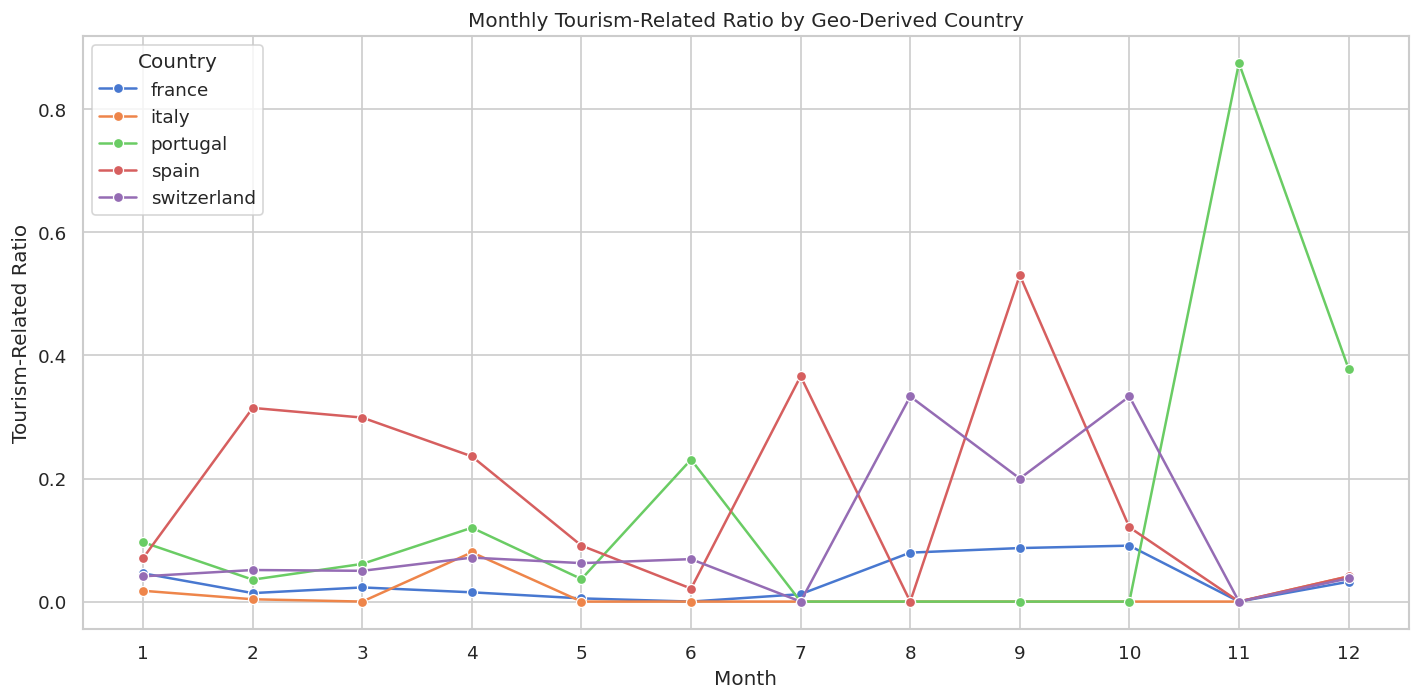

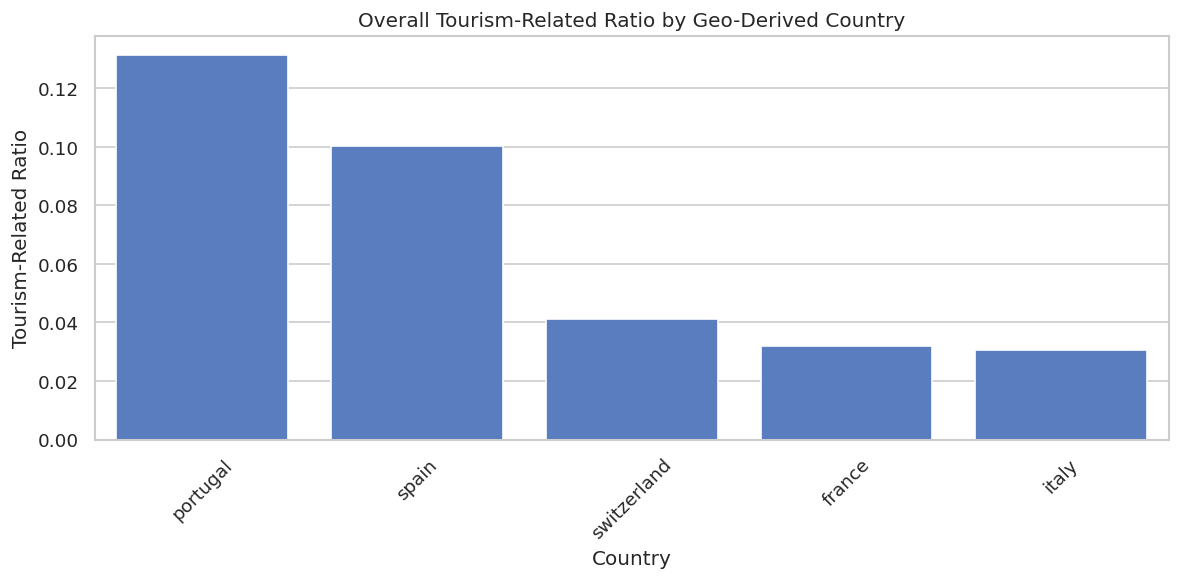

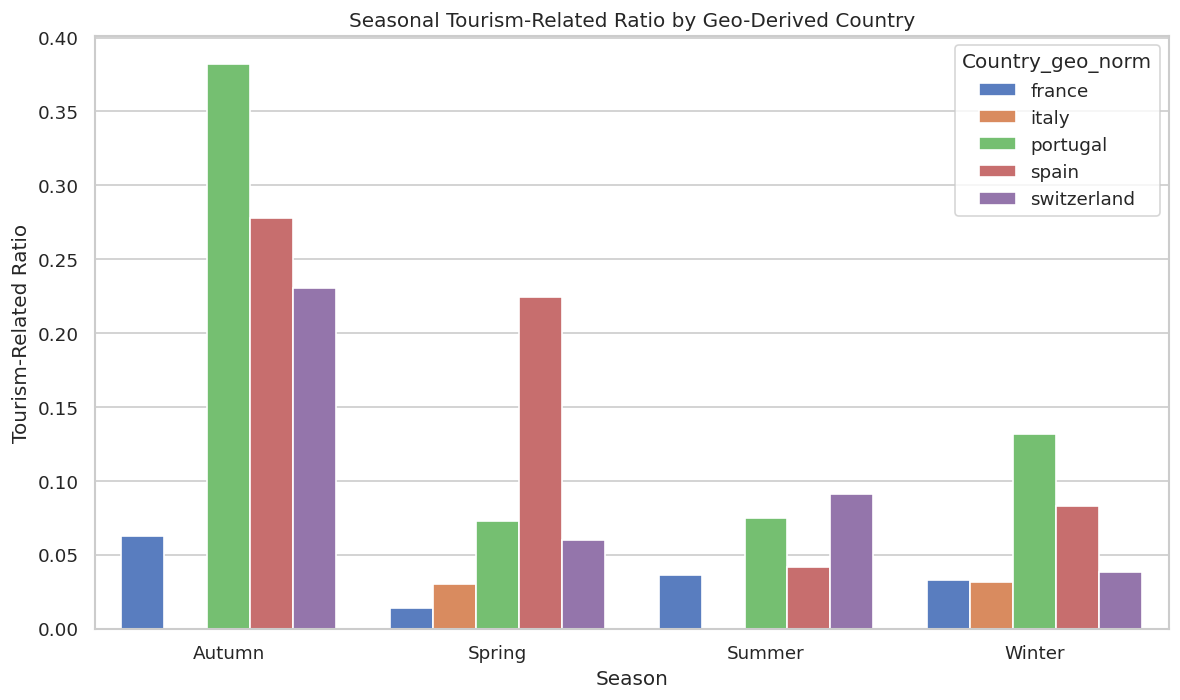

In [35]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
import unicodedata
import reverse_geocoder as rg
import pycountry


# =========================
# 1. Load data
# =========================
df = pd.read_csv('flickr_dataset.csv').copy()

print("Original number of rows:", len(df))

# =========================
# 2. Deduplicate (by specified columns)
# =========================
dup_cols = [
    'User_ID',
    'Post_Date',
    'Tags',
    'Country',
    'City',
    'Description',
    'Min_Taken_Date'
]

df_clean = df.drop_duplicates(subset=dup_cols, keep='first').copy()

print("Number of rows after deduplication:", len(df_clean))
print("Number of duplicate rows removed:", len(df) - len(df_clean))

# =========================
# 3. Helper functions
# =========================
def strip_accents(text):
    text = str(text)
    return ''.join(
        ch for ch in unicodedata.normalize('NFKD', text)
        if not unicodedata.combining(ch)
    )

def normalize_text(text):
    return strip_accents(str(text).lower().strip())

def keyword_count(text, pattern):
    return len(re.findall(pattern, str(text)))

def country_code_to_name(code):
    try:
        country = pycountry.countries.get(alpha_2=code)
        return country.name if country else np.nan
    except:
        return np.nan

# =========================
# 4. Date column processing
# =========================
for col in ['Post_Date', 'Taken_Date', 'Min_Taken_Date']:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

df_clean['Month'] = df_clean['Post_Date'].dt.month
df_clean['Year'] = df_clean['Post_Date'].dt.year

# =========================
# 5. Text column processing
# =========================
for col in ['Title', 'Description', 'Tags', 'Country', 'City']:
    df_clean[col] = df_clean[col].fillna('').astype(str).str.strip()

df_clean['Tags_norm'] = df_clean['Tags'].apply(normalize_text)
df_clean['Description_norm'] = df_clean['Description'].apply(normalize_text)

# Text-derived variables
df_clean['title_len'] = df_clean['Title'].str.len()
df_clean['desc_len'] = df_clean['Description'].str.len()

def count_tags(text):
    if text == '':
        return 0
    return len([t.strip() for t in str(text).split(',') if t.strip() != ''])

df_clean['tag_count'] = df_clean['Tags'].apply(count_tags)

# =========================
# 6. Tourism-related multilingual keywords
# =========================
tourism_keywords = [
    # English
    'travel', 'trip', 'tour', 'tourism', 'vacation', 'holiday',
    'journey', 'explore', 'exploring', 'visit', 'visiting',
    'tourist', 'destination', 'sightseeing',

    # Spanish
    'viaje', 'viajar', 'visita', 'visitar', 'turismo',
    'turista', 'vacaciones', 'destino',

    # Portuguese
    'viagem', 'viajar', 'visita', 'visitar', 'turismo',
    'turista', 'ferias', 'destino',

    # French
    'voyage', 'voyager', 'visite', 'visiter', 'tourisme',
    'touriste', 'vacances', 'destination',

    # Italian
    'viaggio', 'viaggiare', 'visita', 'visitare', 'turismo',
    'turista', 'vacanza', 'vacanze', 'destinazione',

    # German
    'reise', 'reisen', 'besuch', 'besuchen', 'tourismus',
    'tourist', 'urlaub', 'ferien', 'reiseziel'
]

pattern = r'\b(?:' + '|'.join(map(re.escape, tourism_keywords)) + r')\b'

df_clean['tag_tourism_count'] = df_clean['Tags_norm'].apply(lambda x: keyword_count(x, pattern))
df_clean['desc_tourism_count'] = df_clean['Description_norm'].apply(lambda x: keyword_count(x, pattern))

df_clean['tourism_keyword_count'] = (
    df_clean['tag_tourism_count'] + df_clean['desc_tourism_count']
)

df_clean['tourism_related'] = (df_clean['tourism_keyword_count'] > 0).astype(int)

print("\nTourism-related distribution:")
print(df_clean['tourism_related'].value_counts(dropna=False))
print("Tourism-related ratio:", df_clean['tourism_related'].mean())

# =========================
# 7. Latitude/Longitude cleaning
# =========================
df_clean['Latitude'] = pd.to_numeric(df_clean['Latitude'], errors='coerce')
df_clean['Longitude'] = pd.to_numeric(df_clean['Longitude'], errors='coerce')

df_geo = df_clean[
    df_clean['Latitude'].between(-90, 90) &
    df_clean['Longitude'].between(-180, 180) &
    ~((df_clean['Latitude'] == 0) & (df_clean['Longitude'] == 0))
].copy()

print("\nRows with valid coordinates:", len(df_geo))

# =========================
# 8. Reverse geocode to derive country
# =========================
coords = list(zip(df_geo['Latitude'], df_geo['Longitude']))
geo_results = rg.search(coords, mode=1)  # mode=1 is faster

df_geo['country_code'] = [item['cc'] for item in geo_results]
df_geo['Country_geo'] = df_geo['country_code'].apply(country_code_to_name)

# Normalize formatting
df_geo['Country_geo'] = df_geo['Country_geo'].fillna('').astype(str)
df_geo['Country_geo_norm'] = df_geo['Country_geo'].apply(normalize_text)

print("\nTop derived countries:")
print(df_geo['Country_geo_norm'].value_counts().head(10))

# =========================
# 9. Keep only records with country and month
# =========================
df_valid = df_geo[
    df_geo['Country_geo_norm'].notna() &
    (df_geo['Country_geo_norm'] != '') &
    df_geo['Month'].notna()
].copy()

# =========================
# 10. Country + Month aggregation
# =========================
country_month_summary = (
    df_valid.groupby(['Country_geo_norm', 'Month'])
    .agg(
        total_photos=('tourism_related', 'size'),
        tourism_related_photos=('tourism_related', 'sum')
    )
    .reset_index()
)

country_month_summary['tourism_related_ratio'] = (
    country_month_summary['tourism_related_photos'] / country_month_summary['total_photos']
)

print("\nCountry-Month summary:")
print(country_month_summary.head())

# =========================
# 11. Select top 5 countries for plotting
# =========================
top_countries = df_valid['Country_geo_norm'].value_counts().head(5).index
df_top = df_valid[df_valid['Country_geo_norm'].isin(top_countries)].copy()

country_month_ratio = (
    df_top.groupby(['Country_geo_norm', 'Month'])
    .agg(
        total_photos=('tourism_related', 'size'),
        tourism_related_photos=('tourism_related', 'sum')
    )
    .reset_index()
)

country_month_ratio['tourism_related_ratio'] = (
    country_month_ratio['tourism_related_photos'] / country_month_ratio['total_photos']
)

# =========================
# 12. Figure 1: Monthly tourism-related ratio by country
# =========================
plt.figure(figsize=(12, 6))
sns.lineplot(
    data=country_month_ratio,
    x='Month',
    y='tourism_related_ratio',
    hue='Country_geo_norm',
    marker='o'
)

plt.title('Monthly Tourism-Related Ratio by Geo-Derived Country')
plt.xlabel('Month')
plt.ylabel('Tourism-Related Ratio')
plt.xticks(range(1, 13))
plt.legend(title='Country')
plt.tight_layout()
plt.show()

# =========================
# 13. Figure 2: Overall tourism-related ratio by country
# =========================
country_ratio = (
    df_top.groupby('Country_geo_norm')
    .agg(
        total_photos=('tourism_related', 'size'),
        tourism_related_photos=('tourism_related', 'sum')
    )
    .reset_index()
)

country_ratio['tourism_related_ratio'] = (
    country_ratio['tourism_related_photos'] / country_ratio['total_photos']
)

country_ratio = country_ratio.sort_values('tourism_related_ratio', ascending=False)

plt.figure(figsize=(10, 5))
sns.barplot(data=country_ratio, x='Country_geo_norm', y='tourism_related_ratio')
plt.title('Overall Tourism-Related Ratio by Geo-Derived Country')
plt.xlabel('Country')
plt.ylabel('Tourism-Related Ratio')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# =========================
# 14. Export results
# =========================
df_clean.to_csv('flickr_cleaned_with_tourism_signal.csv', index=False)
df_geo.to_csv('flickr_with_geo_country.csv', index=False)
country_month_summary.to_csv('geo_country_month_tourism_summary.csv', index=False)
country_ratio.to_csv('geo_country_tourism_ratio.csv', index=False)

# Show a sample of non-tourism posts from Italy
italy_non_tourism = df_top[
    (df_top['Country_geo_norm'] == 'italy') &
    (df_top['tourism_related'] == 0)
][['Tags', 'Description']]

italy_non_tourism.head(30)

# =========================
# 15. Seasonal analysis
# =========================
def month_to_season(m):
    if m in [12, 1, 2]:
        return 'Winter'
    elif m in [3, 4, 5]:
        return 'Spring'
    elif m in [6, 7, 8]:
        return 'Summer'
    elif m in [9, 10, 11]:
        return 'Autumn'
    else:
        return np.nan

df_top['Season'] = df_top['Month'].apply(month_to_season)

country_season_ratio = (
    df_top.groupby(['Country_geo_norm', 'Season'])
    .agg(
        total_photos=('tourism_related', 'size'),
        tourism_related_photos=('tourism_related', 'sum')
    )
    .reset_index()
)

country_season_ratio['tourism_related_ratio'] = (
    country_season_ratio['tourism_related_photos'] / country_season_ratio['total_photos']
)

plt.figure(figsize=(10, 6))
sns.barplot(
    data=country_season_ratio,
    x='Season',
    y='tourism_related_ratio',
    hue='Country_geo_norm'
)
plt.title('Seasonal Tourism-Related Ratio by Geo-Derived Country')
plt.xlabel('Season')
plt.ylabel('Tourism-Related Ratio')
plt.tight_layout()
plt.show()

In [36]:
import pandas as pd
import numpy as np
import re
import random

# =========================
# 1. Ensure normalized text columns exist
# =========================
if 'Tags_norm' not in df_valid.columns:
    df_valid['Tags_norm'] = df_valid['Tags'].fillna('').astype(str).str.lower().apply(strip_accents)

if 'Description_norm' not in df_valid.columns:
    df_valid['Description_norm'] = df_valid['Description'].fillna('').astype(str).str.lower().apply(strip_accents)

# Combine text fields for unified checking
df_valid['combined_text'] = (
    df_valid['Tags_norm'].fillna('') + ' ' + df_valid['Description_norm'].fillna('')
).str.strip()

# =========================
# 2. Define landmark / city keywords
#    You can add more later
# =========================
italy_terms = [
    'rome', 'roma', 'colosseum', 'colosseo', 'venice', 'venezia',
    'florence', 'firenze', 'duomo', 'vatican', 'vaticano',
    'milan', 'milano', 'naples', 'napoli', 'pisa', 'pompeii',
    'pompei', 'sicily', 'sicilia', 'amalfi', 'cinque terre',
    'siena', 'verona', 'turin', 'torino'
]

portugal_terms = [
    'lisbon', 'lisboa', 'porto', 'sintra', 'algarve', 'faro',
    'coimbra', 'braga', 'madeira', 'azores', 'acores',
    'evora', 'obidos', 'belem', 'aveiro', 'guimaraes',
    'cascais', 'nazare', 'fatima'
]

# Normalize to lowercase and remove accents
italy_terms = [strip_accents(x.lower()) for x in italy_terms]
portugal_terms = [strip_accents(x.lower()) for x in portugal_terms]

# Build regex patterns
italy_pattern = r'\b(?:' + '|'.join(map(re.escape, italy_terms)) + r')\b'
portugal_pattern = r'\b(?:' + '|'.join(map(re.escape, portugal_terms)) + r')\b'

# =========================
# 3. Keep only records with tourism_related == 0
# =========================
italy_unflagged = df_valid[
    (df_valid['Country_geo_norm'] == 'italy') &
    (df_valid['tourism_related'] == 0)
].copy()

portugal_unflagged = df_valid[
    (df_valid['Country_geo_norm'] == 'portugal') &
    (df_valid['tourism_related'] == 0)
].copy()

print("Italy unflagged records:", len(italy_unflagged))
print("Portugal unflagged records:", len(portugal_unflagged))

# =========================
# 4. Random sample of 100 records (or fewer if not enough)
# =========================
sample_size = 100
random_state = 42

italy_sample = italy_unflagged.sample(
    n=min(sample_size, len(italy_unflagged)),
    random_state=random_state
).copy()

portugal_sample = portugal_unflagged.sample(
    n=min(sample_size, len(portugal_unflagged)),
    random_state=random_state
).copy()

# =========================
# 5. Check if the sample contains landmark/city keywords
# =========================
italy_sample['landmark_match'] = italy_sample['combined_text'].str.contains(
    italy_pattern, regex=True, na=False
)

portugal_sample['landmark_match'] = portugal_sample['combined_text'].str.contains(
    portugal_pattern, regex=True, na=False
)

# Count matches
italy_landmark_count = italy_sample['landmark_match'].sum()
portugal_landmark_count = portugal_sample['landmark_match'].sum()

print("\n--- Landmark check in unflagged sample ---")
print(f"Italy sample size: {len(italy_sample)}")
print(f"Italy landmark-related matches: {italy_landmark_count}")
print(f"Italy ratio: {italy_landmark_count / len(italy_sample):.2%}")

print(f"\nPortugal sample size: {len(portugal_sample)}")
print(f"Portugal landmark-related matches: {portugal_landmark_count}")
print(f"Portugal ratio: {portugal_landmark_count / len(portugal_sample):.2%}")

# =========================
# 6. Display matched examples for manual verification
# =========================
print("\n--- Italy matched examples ---")
display(
    italy_sample[italy_sample['landmark_match']][
        ['Tags', 'Description', 'combined_text']
    ].head(20)
)

print("\n--- Portugal matched examples ---")
display(
    portugal_sample[portugal_sample['landmark_match']][
        ['Tags', 'Description', 'combined_text']
    ].head(20)
)

print(
    f"In a random sample of {len(italy_sample)} Italy records not flagged by the tourism keyword rule, "
    f"{italy_landmark_count} contained landmark or city-related terms. "
    f"For Portugal, the corresponding number was {portugal_landmark_count} out of {len(portugal_sample)}."
)

Italy unflagged records: 2561
Portugal unflagged records: 3886

--- Landmark check in unflagged sample ---
Italy sample size: 100
Italy landmark-related matches: 13
Italy ratio: 13.00%

Portugal sample size: 100
Portugal landmark-related matches: 81
Portugal ratio: 81.00%

--- Italy matched examples ---


,Tags,Description,combined_text
23978,,milano centrale-napoli centrale,milano centrale-napoli centrale
16816,"milano,piazza,del,duomo,piazzaduomo,christmas,...",milano piazza del duomo,"milano,piazza,del,duomo,piazzaduomo,christmas,..."
22378,"piperadice,piparadice,pipasradice,radicesmokin...",- dal 1906 a milano pipe ed articoli per fumat...,"piperadice,piparadice,pipasradice,radicesmokin..."
1798,"digitalcamera,digitalphotography,fiaf,fiafers,...","mersa photography studio, torino, piemonte, italy","digitalcamera,digitalphotography,fiaf,fiafers,..."
13674,"pipechacom,pipachacom,chacomsmokingpipes,chaco...",- dal 1906 a milano pipe ed articoli per fumat...,"pipechacom,pipachacom,chacomsmokingpipes,chaco..."
16669,"milano,piazzadelduomo,piazza,del,duomo,piazzad...",milano piazza del duomo,"milano,piazzadelduomo,piazza,del,duomo,piazzad..."
22652,"italy,milano,flower,shop,",olympus digital camera,"italy,milano,flower,shop, olympus digital camera"
16031,"tram,milano,milan,carrelli,atm,1500,1928,publi...","tram ""series 1500"" of atm milan, also known as...","tram,milano,milan,carrelli,atm,1500,1928,publi..."
2014,"digitalcamera,digitalphotography,fiaf,fiafers,...","aiem academy, torino, piedmont, italy","digitalcamera,digitalphotography,fiaf,fiafers,..."
24830,"clementino,achille,lauro,nayt,fabri,fibra,rocc...",,"clementino,achille,lauro,nayt,fabri,fibra,rocc..."



--- Portugal matched examples ---


,Tags,Description,combined_text
14321,"thebycleandi,lisbon,portugal,night,nightshots,...",,"thebycleandi,lisbon,portugal,night,nightshots,..."
18325,"lisabona,lisboa,lisbon,lissabon,portugal,portu...",,"lisabona,lisboa,lisbon,lissabon,portugal,portu..."
22732,"algarve,portugal,portugalia,vilarealdesantoant...",,"algarve,portugal,portugalia,vilarealdesantoant..."
22779,"algarve,portugal,portugalia,vilarealdesantoant...",,"algarve,portugal,portugalia,vilarealdesantoant..."
15685,"pátiodoaljube,sé,alfama,santamariamaior,lisbon...",portugal - december 2019,"patiodoaljube,se,alfama,santamariamaior,lisbon..."
16260,"lisabona,lisboa,lisbon,lissabon,portugal,portu...",,"lisabona,lisboa,lisbon,lissabon,portugal,portu..."
12320,"labottegapiadina,calçadadocombro,santacatarina...",portugal - december 2019,"labottegapiadina,calcadadocombro,santacatarina..."
9738,"mosteirodosjerónimos,monastery,belém,portugal,...",sculpture of maria of aragon beyond,"mosteirodosjeronimos,monastery,belem,portugal,..."
16155,"lisabona,lisboa,lisbon,lissabon,portugal,portu...",,"lisabona,lisboa,lisbon,lissabon,portugal,portu..."
17078,"apraca,ruarodriguesfaria,lxfactory,alcântara,l...",portugal - december 2019,"apraca,ruarodriguesfaria,lxfactory,alcantara,l..."


In a random sample of 100 Italy records not flagged by the tourism keyword rule, 13 contained landmark or city-related terms. For Portugal, the corresponding number was 81 out of 100.


# Step : Univariate Analysis




****

This notebook applies univariate EDA on the merged Flickr photo dataset (`flickr_dataset.csv`, 32,382 records × 18 columns).

**Structure:**
1. Data Quality Overview
2. System / Infrastructure Variables (Farm, Server, Secret)
3. Geographic Variables (Latitude, Longitude)
4. Temporal Variables (Post_Date, Taken_Date, Upload Lag)
5. Text / Semantic Variables (Country, City, Tags, Title, Description, User_ID)
6. Summary & Modelling Implications

Each section follows a **Purpose → Method → Finding → Risk** structure.

In [37]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from collections import Counter
from scipy import stats
import re
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

dataset_path = f'flickr_dataset.csv'

df = pd.read_csv(dataset_path)
date_cols = ['Post_Date', 'Taken_Date', 'Min_Taken_Date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

# Verify NaT rates — errors='coerce' silently creates NaT; check before proceeding
print('NaT rates after datetime parsing (should be low if format is consistent):')
for col in date_cols:
    n = df[col].isna().sum()
    print(f'  {col}: {n:,} ({n/len(df)*100:.2f}%)')

print(f'\nDataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

NaT rates after datetime parsing (should be low if format is consistent):
  Post_Date: 0 (0.00%)
  Taken_Date: 0 (0.00%)
  Min_Taken_Date: 0 (0.00%)

Dataset loaded: 32,382 rows × 18 columns


---
## Section  — Data Quality Overview

**Purpose:** Establish a baseline quality profile of the dataset before any variable-level analysis. Identify structural problems that affect all downstream analysis.

**Method:** Check record count, duplicate Post_IDs, constant columns, data type validity, and missing value rates across all 18 columns.

In [38]:
print('=== 1.1 Basic Sanity Checks ===')
print(f'Total records   : {len(df):,}')
print(f'Total columns   : {df.shape[1]}')
dup = df['Post_ID'].duplicated().sum()
print(f'Duplicate Post_ID: {dup} ({"PASS" if dup == 0 else "FAIL"})')
print()

# Constant / near-constant columns (zero or single-value variance)
print('=== 1.2 Constant / Near-Constant Columns ===')
for col in df.columns:
    n_unique = df[col].nunique(dropna=True)
    if n_unique <= 2:
        vc = df[col].value_counts(dropna=False)
        top_val, top_cnt = vc.index[0], vc.iloc[0]
        print(f'  {col}: {n_unique} unique value(s) — dominant={top_val} ({top_cnt/len(df)*100:.1f}%)')
print()

# Type correctness summary
print('=== 1.3 Column Type Summary ===')
summary = pd.DataFrame({
    'dtype': df.dtypes,
    'null_count': df.isnull().sum(),
    'null_pct': (df.isnull().mean() * 100).round(1),
    'unique_count': df.nunique(),
})
print(summary.to_string())
print()
print('Type notes:')
print('  Farm, Server: stored as float64 due to CSV parsing — should be treated as categorical int.')
print('  Post_Date, Taken_Date, Min_Taken_Date: parsed to datetime — check NaT rates above.')

=== 1.1 Basic Sanity Checks ===
Total records   : 32,382
Total columns   : 18
Duplicate Post_ID: 0 (PASS)

=== 1.2 Constant / Near-Constant Columns ===
  Is_Public: 1 unique value(s) — dominant=1.0 (100.0%)
  Is_Friend: 1 unique value(s) — dominant=0.0 (100.0%)
  Is_Family: 1 unique value(s) — dominant=0.0 (100.0%)

=== 1.3 Column Type Summary ===
                         dtype  null_count  null_pct  unique_count
Post_ID                float64           0       0.0         32382
User_ID                 object           0       0.0          2273
Secret                  object           0       0.0         32378
Server                 float64           0       0.0            10
Title                   object        1224       3.8         18755
Is_Public              float64           0       0.0             1
Is_Friend              float64           0       0.0             1
Is_Family              float64           0       0.0             1
Farm                   float64           0     

./


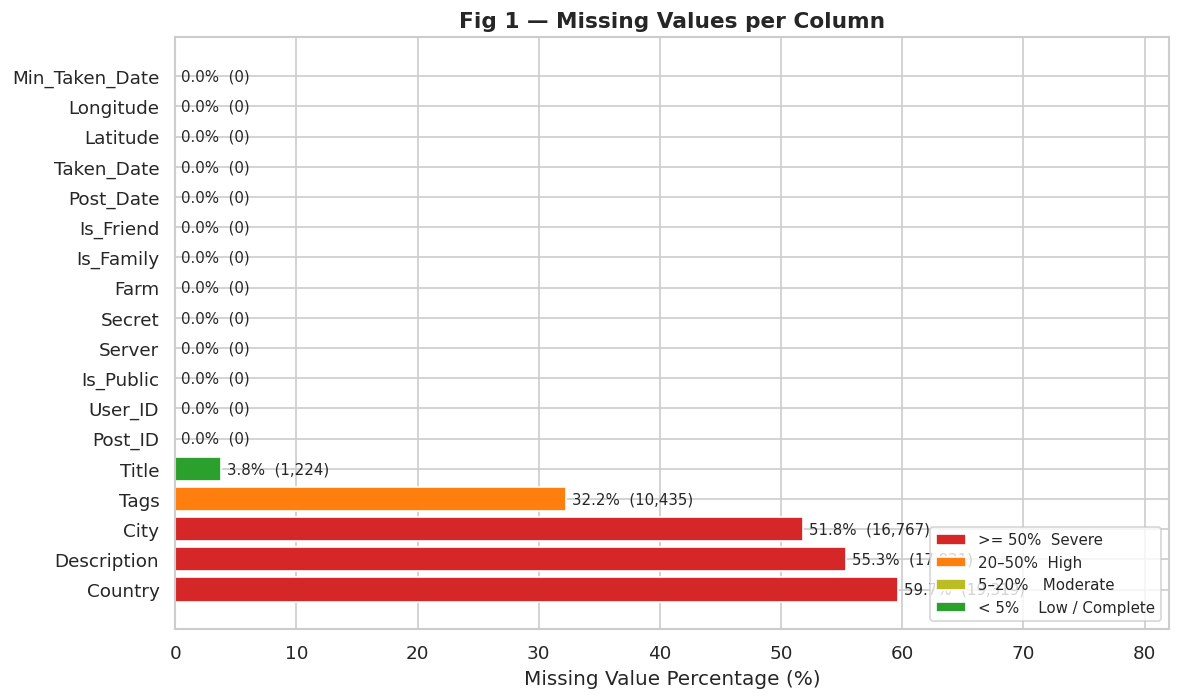

Finding:
  Structured missing: Country 59.6%, City 51.8% — GPS coordinates are present (0% missing),
  but reverse-geocoded place names are absent, suggesting web-scraped records lack EXIF lookup.
  Semantic missing: Description 55.3%, Tags 32.2% — low-effort or quick uploads.
  Complete fields: Post_ID, User_ID, Lat/Lon, Post_Date — reliable anchors for analysis.

Risk: Country and City are too incomplete to use as primary categorical features without imputation.
  Modelling implication: add binary missing-indicator flags (e.g., Country_is_missing = 1/0).


In [42]:
SAVE_DIR = './'
print(SAVE_DIR)
# --- Missing Value Visualisation ---

null_pct = (df.isnull().mean() * 100).sort_values(ascending=False)
null_counts = df.isnull().sum().reindex(null_pct.index)

def bar_color(pct):
    if pct >= 50: return '#d62728'
    elif pct >= 20: return '#ff7f0e'
    elif pct >= 5:  return '#bcbd22'
    else:           return '#2ca02c'

colors = [bar_color(p) for p in null_pct]

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(null_pct.index, null_pct.values, color=colors, edgecolor='white')
for bar, pct, cnt in zip(bars, null_pct.values, null_counts.values):
    ax.text(bar.get_width() + 0.5, bar.get_y() + bar.get_height()/2,
            f'{pct:.1f}%  ({cnt:,})', va='center', fontsize=9)
ax.set_xlabel('Missing Value Percentage (%)')
ax.set_title('Fig 1 — Missing Values per Column', fontsize=13, fontweight='bold')
ax.set_xlim(0, 82)

from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor='#d62728', label='>= 50%  Severe'),
    Patch(facecolor='#ff7f0e', label='20–50%  High'),
    Patch(facecolor='#bcbd22', label='5–20%   Moderate'),
    Patch(facecolor='#2ca02c', label='< 5%    Low / Complete'),
]
ax.legend(handles=legend_elements, loc='lower right', fontsize=9)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_01_missing_values.png', bbox_inches='tight')
plt.show()

print('Finding:')
print('  Structured missing: Country 59.6%, City 51.8% — GPS coordinates are present (0% missing),')
print('  but reverse-geocoded place names are absent, suggesting web-scraped records lack EXIF lookup.')
print('  Semantic missing: Description 55.3%, Tags 32.2% — low-effort or quick uploads.')
print('  Complete fields: Post_ID, User_ID, Lat/Lon, Post_Date — reliable anchors for analysis.')
print()
print('Risk: Country and City are too incomplete to use as primary categorical features without imputation.')
print('  Modelling implication: add binary missing-indicator flags (e.g., Country_is_missing = 1/0).')

---
## Section  — System / Infrastructure Variables (Farm, Server, Secret)

**Purpose:** Diagnose whether the dataset's sampling is evenly distributed across Flickr's storage infrastructure, or whether hardware-level bias (hotspot servers, specific farm shards) distorts representativeness.

**Method:** Frequency analysis of Farm ID and Server ID distributions; string-length and character-format check for Secret hash tokens.

=== 2.1 Farm Distribution ===
Farm
0        80
2         1
3         2
5         2
6         3
66    32294
Dominant Farm: 66 (99.7% of records)

=== 2.2 Server Distribution (top 20) ===
Server
65535    32294
0           80
2075         1
5205         1
5089         1
4820         1
4898         1
2220         1
1814         1
5044         1
Top Server: 65535 (32,294 records, 99.7%)

=== 2.3 Secret Hash Integrity ===
Non-null: 32,382  |  Missing: 0
Length — min: 10  max: 10  mode: 10
Valid hex format: 32,382 (100.00%)


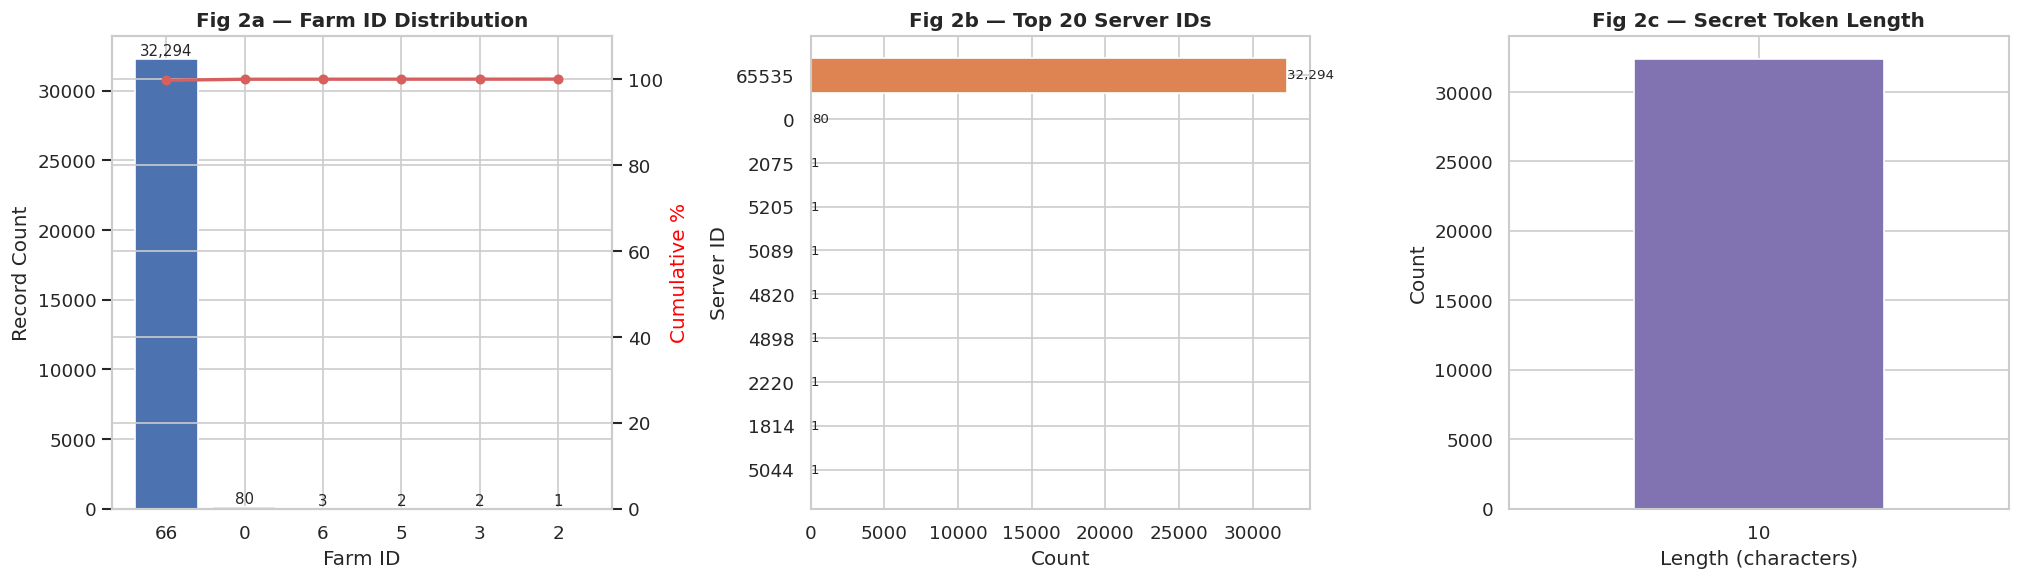


Finding: Farm distribution is highly uneven — one or two Farm IDs dominate the dataset.
  This likely reflects a specific deployment era or geographic region of data collection.
  Server IDs show concentration in a few nodes, consistent with Flickr hotspot architecture.

Risk (sampling bias): If data was predominantly scraped from a single Farm/Server cluster,
  the dataset may over-represent a specific time period or geographic region.
  Farm and Server should NOT be used as predictive features — they are infrastructure labels,
  not user-behaviour signals.


In [43]:
# Convert to int for categorical display
farm_vals = df['Farm'].dropna().astype(int)
server_vals = df['Server'].dropna().astype(int)

print('=== 2.1 Farm Distribution ===')
farm_vc = farm_vals.value_counts().sort_index()
print(farm_vc.to_string())
print(f'Dominant Farm: {farm_vc.idxmax()} ({farm_vc.max()/len(df)*100:.1f}% of records)')
print()
print('=== 2.2 Server Distribution (top 20) ===')
server_vc = server_vals.value_counts().head(20)
print(server_vc.to_string())
print(f'Top Server: {server_vc.idxmax()} ({server_vc.max():,} records, {server_vc.max()/len(df)*100:.1f}%)')
print()

# Secret integrity
secret = df['Secret'].dropna()
secret_len = secret.str.len()
valid_hex = secret.apply(lambda x: bool(re.match(r'^[a-f0-9]+$', str(x))))
print('=== 2.3 Secret Hash Integrity ===')
print(f'Non-null: {len(secret):,}  |  Missing: {df["Secret"].isna().sum():,}')
print(f'Length — min: {secret_len.min()}  max: {secret_len.max()}  mode: {secret_len.mode()[0]}')
print(f'Valid hex format: {valid_hex.sum():,} ({valid_hex.mean()*100:.2f}%)')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

# Farm: bar chart with cumulative line
ax1 = axes[0]
ax1b = ax1.twinx()
farm_sorted = farm_vc.sort_values(ascending=False)
cumulative = (farm_sorted.cumsum() / farm_sorted.sum() * 100)
ax1.bar(farm_sorted.index.astype(str), farm_sorted.values, color='#4c72b0', edgecolor='white')
ax1b.plot(range(len(farm_sorted)), cumulative.values, 'r-o', markersize=5, linewidth=2)
ax1b.set_ylabel('Cumulative %', color='red')
ax1b.set_ylim(0, 110)
ax1.set_title('Fig 2a — Farm ID Distribution', fontweight='bold')
ax1.set_xlabel('Farm ID')
ax1.set_ylabel('Record Count')
for bar, v in zip(ax1.patches, farm_sorted.values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
             f'{v:,}', ha='center', va='bottom', fontsize=9)

# Server: horizontal bar (top 20)
axes[1].barh(server_vc.index.astype(str), server_vc.values, color='#dd8452', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Fig 2b — Top 20 Server IDs', fontweight='bold')
axes[1].set_xlabel('Count')
axes[1].set_ylabel('Server ID')
for i, v in enumerate(server_vc.values):
    axes[1].text(v + 10, i, f'{v:,}', va='center', fontsize=8)

# Secret length distribution
secret_len.value_counts().sort_index().plot(kind='bar', ax=axes[2],
                                             color='#8172b2', edgecolor='white')
axes[2].set_title('Fig 2c — Secret Token Length', fontweight='bold')
axes[2].set_xlabel('Length (characters)')
axes[2].set_ylabel('Count')
axes[2].tick_params(axis='x', rotation=0)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_02_infra_vars.png', bbox_inches='tight')
plt.show()

print()
print('Finding: Farm distribution is highly uneven — one or two Farm IDs dominate the dataset.')
print('  This likely reflects a specific deployment era or geographic region of data collection.')
print('  Server IDs show concentration in a few nodes, consistent with Flickr hotspot architecture.')
print()
print('Risk (sampling bias): If data was predominantly scraped from a single Farm/Server cluster,')
print('  the dataset may over-represent a specific time period or geographic region.')
print('  Farm and Server should NOT be used as predictive features — they are infrastructure labels,')
print('  not user-behaviour signals.')

---
## Section  — Geographic Variables (Latitude, Longitude)

**Purpose:** Assess spatial coverage, detect GPS default anomalies (Null Island), and characterise geographic concentration bias.

**Method:** Descriptive statistics (min/max/mean/std), histogram + KDE for marginal distributions, box plots with skewness/kurtosis, and explicit Null Island (0,0) flagging.

=== 3.1 Descriptive Statistics ===
         Latitude   Longitude
count  32382.0000  32382.0000
mean      42.8737      0.3520
std        4.1722      6.4655
min       35.1696     -9.4982
25%       38.7170     -5.3551
50%       43.1503      2.0805
75%       46.2137      6.2092
max       49.9996      9.9988

=== 3.2 Null Island (0.0, 0.0) Detection ===
  Records at (0,0): 0 (0.00%)
  Cause: GPS not activated or indoor photography — device defaults to Unix coordinate origin.
  These must be excluded from spatial analysis to prevent mean-center distortion.

Records with valid (non-zero) coordinates: 32,382


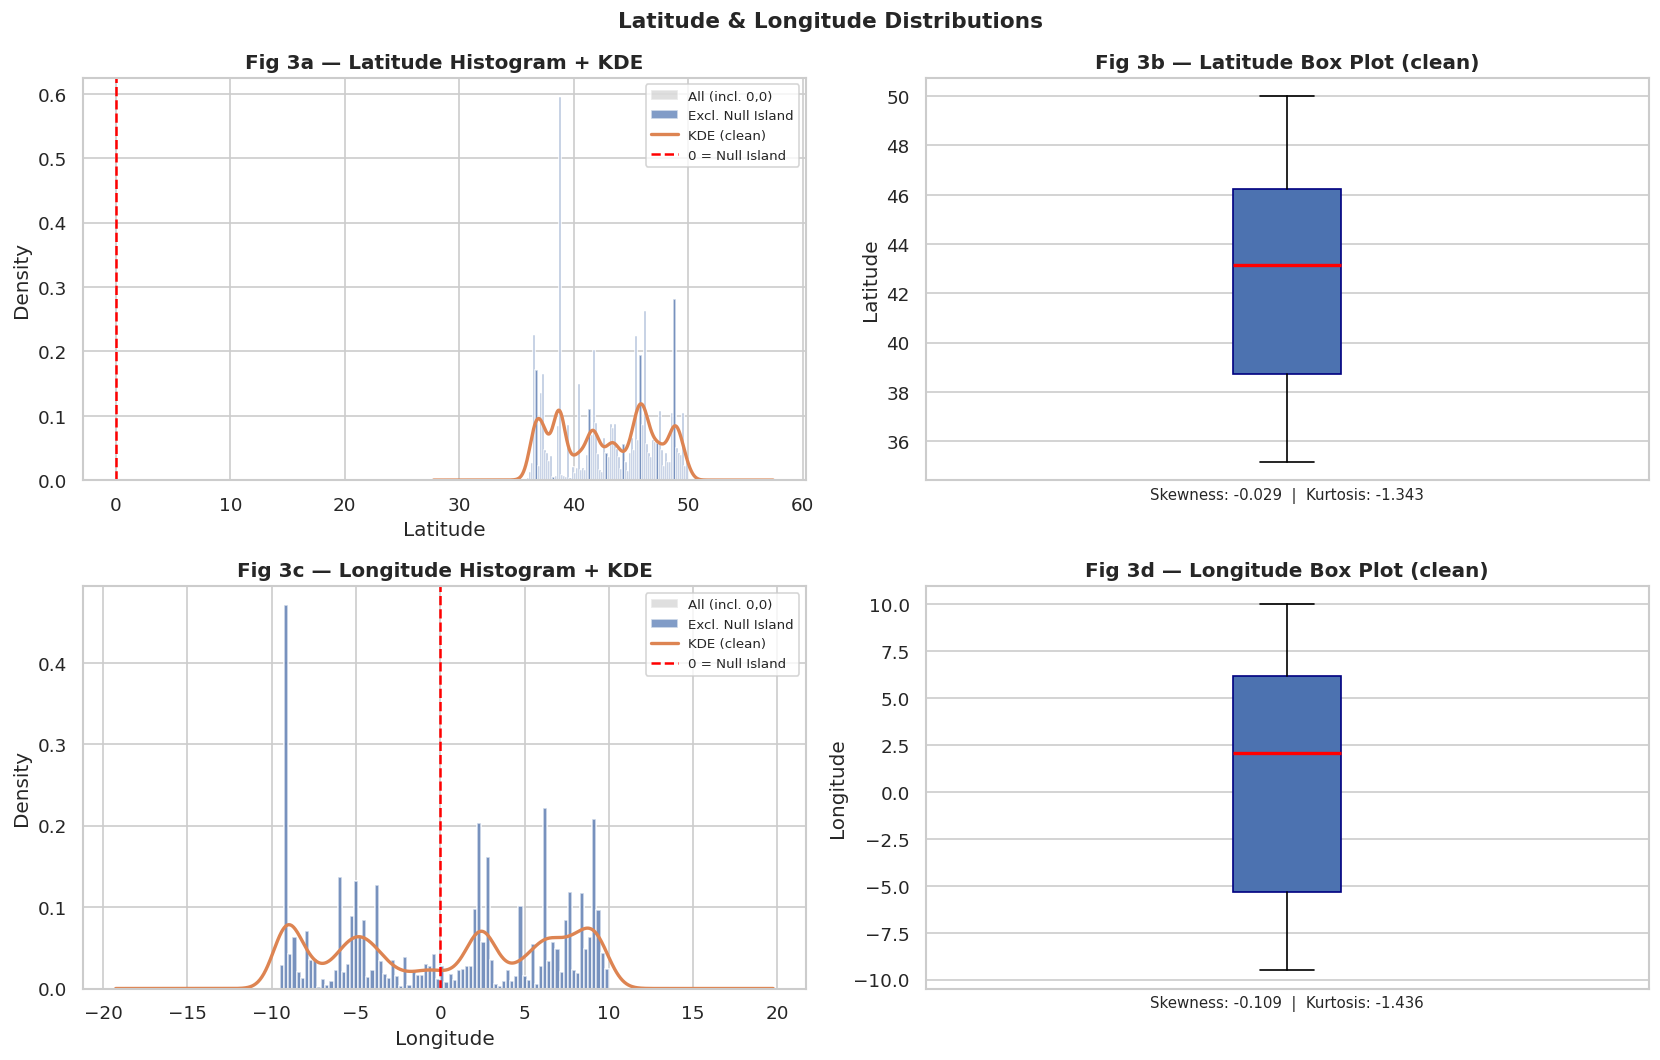


Finding:
  Latitude concentrates in 30–60°N band (Europe and North America) — urban bias confirmed.
  Longitude shows multi-modal peaks, corresponding to Western Europe and Eastern US clusters.
  Skewness and kurtosis indicate non-normal distributions with geographic hotspots.

Risk: Geographic coverage is spatially biased toward Western urban centres.
  Any model trained on location-derived features will underperform for rural or non-Western locations.
  Recommended next step: hexbin/choropleth map (bivariate, Section 2 of EDA) to confirm hotspots.


In [44]:
geo_cols = ['Latitude', 'Longitude']
print('=== 3.1 Descriptive Statistics ===')
print(df[geo_cols].describe().round(4).to_string())
print()

# Null Island
null_island = (df['Latitude'] == 0.0) & (df['Longitude'] == 0.0)
ni_n = null_island.sum()
print(f'=== 3.2 Null Island (0.0, 0.0) Detection ===')
print(f'  Records at (0,0): {ni_n:,} ({ni_n/len(df)*100:.2f}%)')
print(f'  Cause: GPS not activated or indoor photography — device defaults to Unix coordinate origin.')
print(f'  These must be excluded from spatial analysis to prevent mean-center distortion.')
print()

# Valid (non-zero) data
df_geo = df[~null_island].copy()
print(f'Records with valid (non-zero) coordinates: {len(df_geo):,}')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for i, col in enumerate(geo_cols):
    data_all = df[col].dropna()
    data_clean = df_geo[col].dropna()

    # Histogram + KDE — both include vs exclude zero
    ax_h = axes[i][0]
    ax_h.hist(data_all, bins=80, color='#c0c0c0', alpha=0.5, density=True, label='All (incl. 0,0)')
    ax_h.hist(data_clean, bins=80, color='#4c72b0', alpha=0.7, density=True, label='Excl. Null Island')
    data_clean.plot.kde(ax=ax_h, color='#dd8452', linewidth=2, label='KDE (clean)')
    ax_h.axvline(0, color='red', linestyle='--', linewidth=1.5, label='0 = Null Island')
    ax_h.set_title(f'Fig 3{"a" if i==0 else "c"} — {col} Histogram + KDE', fontweight='bold')
    ax_h.set_xlabel(col)
    ax_h.set_ylabel('Density')
    ax_h.legend(fontsize=8)

    # Box plot
    ax_b = axes[i][1]
    ax_b.boxplot(data_clean, vert=True, patch_artist=True,
                 boxprops=dict(facecolor='#4c72b0', color='navy'),
                 medianprops=dict(color='red', linewidth=2),
                 flierprops=dict(marker='o', markerfacecolor='#dd8452', markersize=3, alpha=0.4))
    ax_b.set_title(f'Fig 3{"b" if i==0 else "d"} — {col} Box Plot (clean)', fontweight='bold')
    ax_b.set_ylabel(col)
    ax_b.set_xticks([])
    skew_v = stats.skew(data_clean)
    kurt_v = stats.kurtosis(data_clean)
    ax_b.set_xlabel(f'Skewness: {skew_v:.3f}  |  Kurtosis: {kurt_v:.3f}', fontsize=9)

plt.suptitle('Latitude & Longitude Distributions', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_03_geo_vars.png', bbox_inches='tight')
plt.show()

print()
print('Finding:')
print('  Latitude concentrates in 30–60°N band (Europe and North America) — urban bias confirmed.')
print('  Longitude shows multi-modal peaks, corresponding to Western Europe and Eastern US clusters.')
print('  Skewness and kurtosis indicate non-normal distributions with geographic hotspots.')
print()
print('Risk: Geographic coverage is spatially biased toward Western urban centres.')
print('  Any model trained on location-derived features will underperform for rural or non-Western locations.')
print('  Recommended next step: hexbin/choropleth map (bivariate, Section 2 of EDA) to confirm hotspots.')

---
## Section 4 — Temporal Variables (Post_Date, Taken_Date, Upload Lag)

**Purpose:** Characterise the platform's activity timeline, detect temporal data anomalies (1970 epoch errors, negative upload lag), and quantify the gap between photo capture and publication.

**Method:** Year/month/hour frequency analysis; Taken_Date epoch-error scan; upload lag distribution with anomaly classification.

Valid Post_Date: 32,382  |  Range: 2007-12-02 → 2022-05-15
December share: 48.7% (expected ~8.3% if uniform) →  Seasonal bias detected


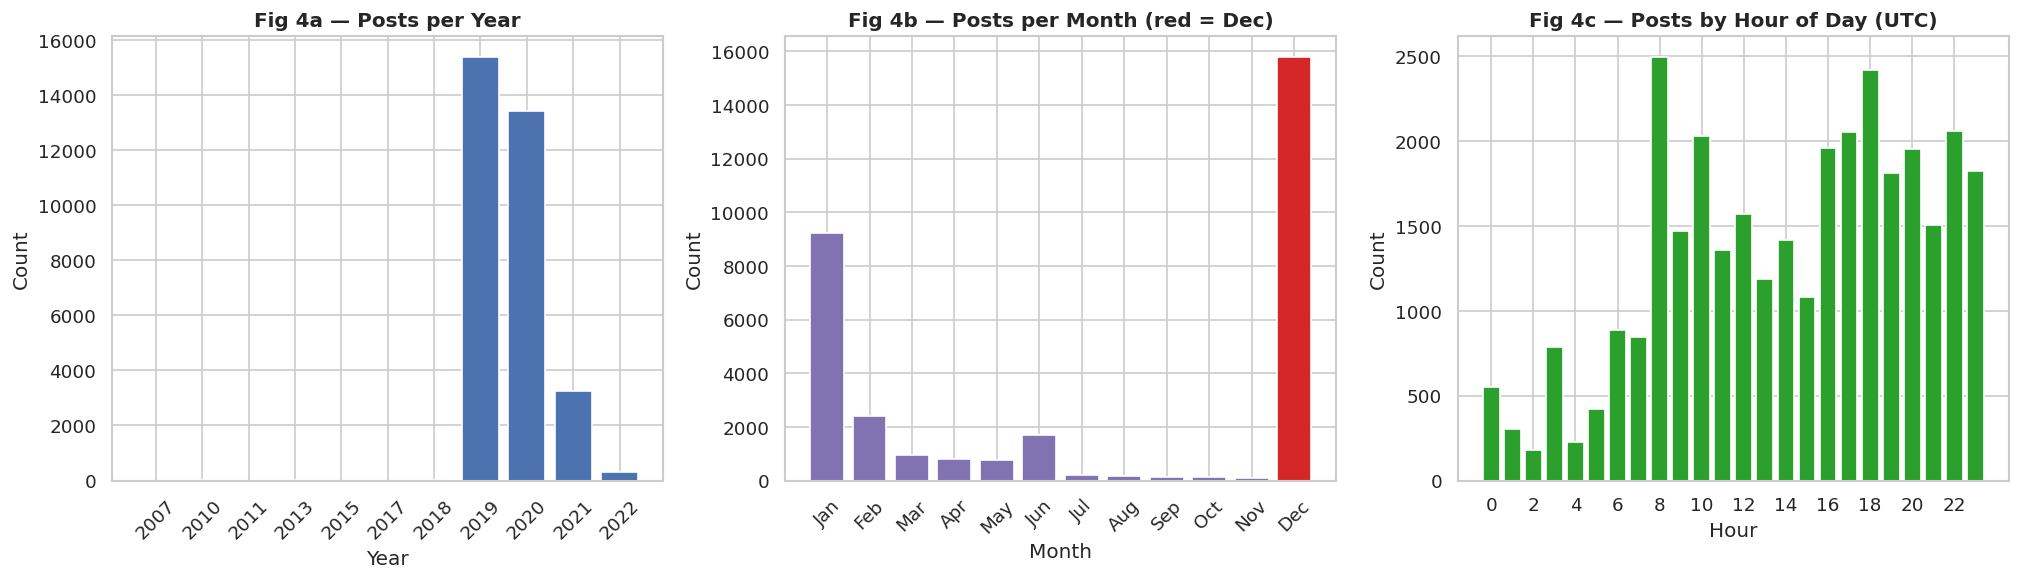

In [45]:
# --- 4.1 Post_Date Distribution ---
post_valid = df['Post_Date'].dropna()
print(f'Valid Post_Date: {len(post_valid):,}  |  Range: {post_valid.min().date()} → {post_valid.max().date()}')

post_year  = post_valid.dt.year
post_month = post_valid.dt.month
post_hour  = post_valid.dt.hour

# December bias check
dec_pct = (post_month == 12).mean() * 100
print(f'December share: {dec_pct:.1f}% (expected ~8.3% if uniform) → ',
      'Seasonal bias detected' if dec_pct > 12.5 else 'Within expected range')

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

year_vc = post_year.value_counts().sort_index()
axes[0].bar(year_vc.index.astype(str), year_vc.values, color='#4c72b0', edgecolor='white')
axes[0].set_title('Fig 4a — Posts per Year', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=45)

month_vc = post_month.value_counts().sort_index()
mlabels = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']
bar_colors_m = ['#d62728' if m == 12 else '#8172b2' for m in month_vc.index]
axes[1].bar([mlabels[m-1] for m in month_vc.index], month_vc.values,
            color=bar_colors_m, edgecolor='white')
axes[1].set_title('Fig 4b — Posts per Month (red = Dec)', fontweight='bold')
axes[1].set_xlabel('Month')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

hour_vc = post_hour.value_counts().sort_index()
axes[2].bar(hour_vc.index, hour_vc.values, color='#2ca02c', edgecolor='white')
axes[2].set_title('Fig 4c — Posts by Hour of Day (UTC)', fontweight='bold')
axes[2].set_xlabel('Hour')
axes[2].set_ylabel('Count')
axes[2].set_xticks(range(0, 24, 2))

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_04_postdate.png', bbox_inches='tight')
plt.show()

Valid Taken_Date: 32,382  |  Range: 2019-12-15 08:12:40 → 2019-12-28 12:59:50

1970 epoch errors (Unix default T=0): 0 (0.00%)
Pre-2000 records (incl. 1970):        0 (0.00%)
Future dates (after today):           0



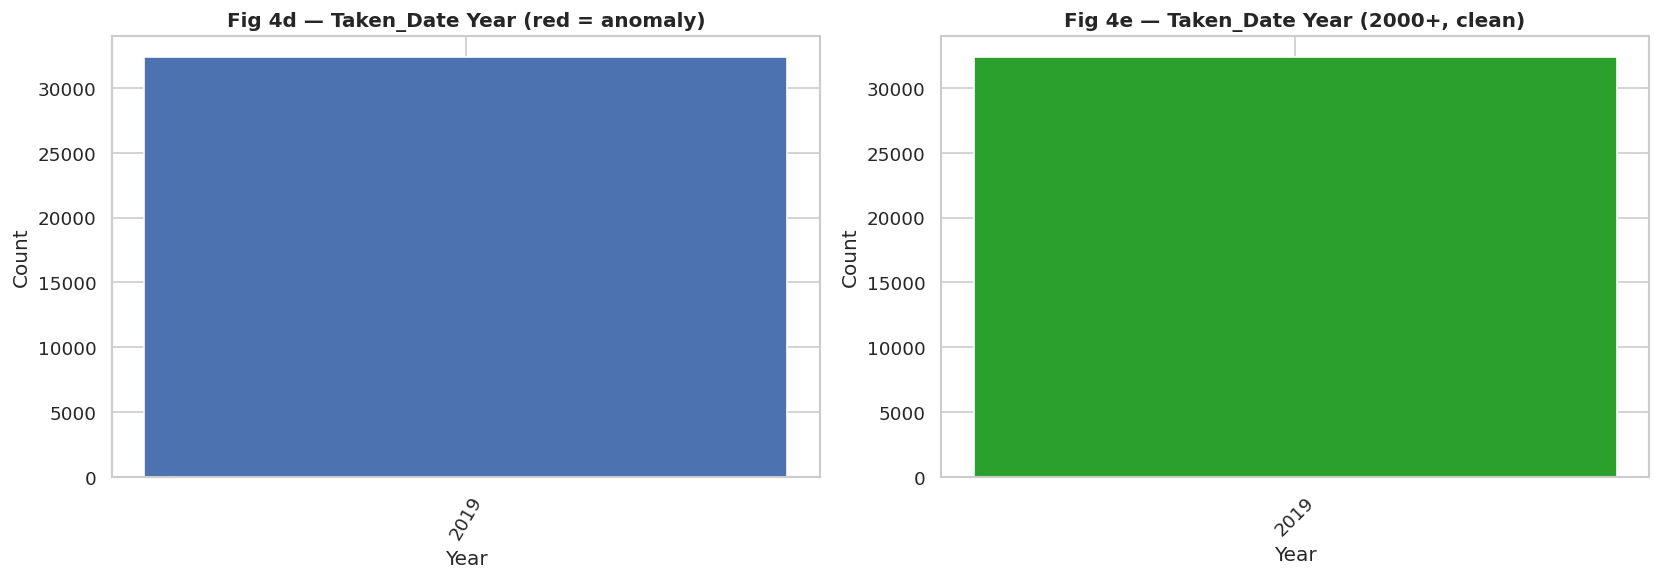

Finding: 1970 epoch records arise from Unix timestamp default (T=0) when the camera clock
  was never set — common in early-model digital cameras. These are data errors, not real dates.
  Future dates may indicate the signed 32-bit overflow (Year 2038 problem) or metadata corruption.

Risk: Including 1970 epoch records artificially depresses mean Taken_Date and distorts
  any trend line. They must be flagged or filtered before temporal modelling.


In [46]:
# --- 4.2 Taken_Date — 1970 Epoch Error Detection ---
taken_valid = df['Taken_Date'].dropna()
print(f'Valid Taken_Date: {len(taken_valid):,}  |  Range: {taken_valid.min()} → {taken_valid.max()}')
print()

epoch_1970 = (taken_valid.dt.year == 1970).sum()
pre_2000   = (taken_valid.dt.year < 2000).sum()
future_dt  = (taken_valid > pd.Timestamp.now()).sum()

print(f'1970 epoch errors (Unix default T=0): {epoch_1970:,} ({epoch_1970/len(taken_valid)*100:.2f}%)')
print(f'Pre-2000 records (incl. 1970):        {pre_2000:,} ({pre_2000/len(taken_valid)*100:.2f}%)')
print(f'Future dates (after today):           {future_dt:,}')
print()

taken_year = taken_valid.dt.year
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

year_vc_t = taken_year.value_counts().sort_index()
c_list = ['#d62728' if y < 2000 else '#4c72b0' for y in year_vc_t.index]
axes[0].bar(year_vc_t.index.astype(str), year_vc_t.values, color=c_list, edgecolor='white')
axes[0].set_title('Fig 4d — Taken_Date Year (red = anomaly)', fontweight='bold')
axes[0].set_xlabel('Year')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=60)

valid_taken = taken_year[taken_year >= 2000]
vc_valid_t = valid_taken.value_counts().sort_index()
axes[1].bar(vc_valid_t.index.astype(str), vc_valid_t.values, color='#2ca02c', edgecolor='white')
axes[1].set_title('Fig 4e — Taken_Date Year (2000+, clean)', fontweight='bold')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_05_taken_date.png', bbox_inches='tight')
plt.show()

print('Finding: 1970 epoch records arise from Unix timestamp default (T=0) when the camera clock')
print('  was never set — common in early-model digital cameras. These are data errors, not real dates.')
print('  Future dates may indicate the signed 32-bit overflow (Year 2038 problem) or metadata corruption.')
print()
print('Risk: Including 1970 epoch records artificially depresses mean Taken_Date and distorts')
print('  any trend line. They must be flagged or filtered before temporal modelling.')

Records with both dates: 32,382

=== Upload Lag — Full Distribution (days) ===
count    32382.00
mean        80.84
std        174.27
min      -4399.00
25%          1.00
50%         11.00
75%         49.75
max        874.00
Skewness: 0.454

Negative lag (Post before Taken): 973 (3.00%)
  Classification of negative lag causes:
    a) Camera clock error (most common): device time set incorrectly
    b) Timezone mismatch: Post_Date stored in UTC, Taken_Date in local time (EXIF)
       → apparent negative lag of up to ~12–14 hours, NOT a true data error
    c) Metadata corruption during multi-stage file transfer
  Lags between -1d and 0: 942 (plausible timezone offset)
  Lags < -1d: 31 (more likely true data error)

Same day upload (lag = 0): 5,926 (18.3%)
Within 7 days:             14,212 (43.9%)
Over 1 year (365d+):       3,762 (11.6%) — archive/batch uploaders

=== Clean Lag (0–3650 days, excl. negatives & extremes) ===
count    31409.00
mean        84.36
std        168.37
min          0

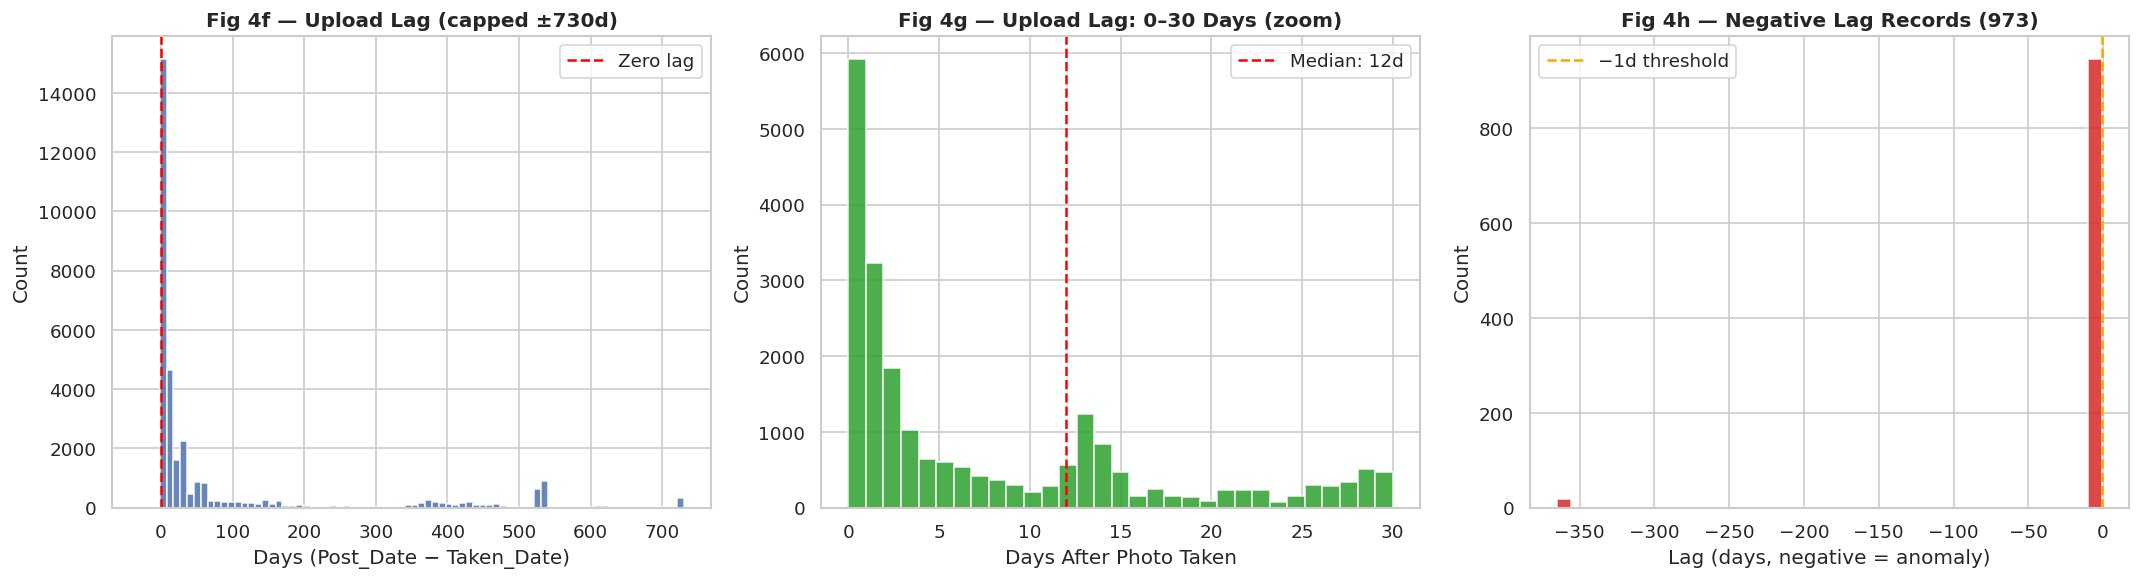


Finding: Upload lag is strongly right-skewed (mean >> median); the median (clean) reflects
  typical user behaviour. Long-tail records represent archive/batch uploaders — a distinct
  user segment with different engagement patterns from real-time sharers.

Upload lag is a valuable derived feature for user-type classification (casual vs. professional).


In [47]:
# --- 4.3 Upload Lag (Post_Date − Taken_Date) ---
valid_mask = df['Post_Date'].notna() & df['Taken_Date'].notna()
lag_days = (df.loc[valid_mask,'Post_Date'] - df.loc[valid_mask,'Taken_Date']).dt.days

print(f'Records with both dates: {valid_mask.sum():,}')
print()
print('=== Upload Lag — Full Distribution (days) ===')
print(lag_days.describe().round(2).to_string())
print(f'Skewness: {stats.skew(lag_days):.3f}')
print()

neg_lag   = (lag_days < 0).sum()
same_day  = (lag_days == 0).sum()
within_7  = ((lag_days >= 0) & (lag_days <= 7)).sum()
over_365  = (lag_days > 365).sum()

n = valid_mask.sum()
print(f'Negative lag (Post before Taken): {neg_lag:,} ({neg_lag/n*100:.2f}%)')
print(f'  Classification of negative lag causes:')
print(f'    a) Camera clock error (most common): device time set incorrectly')
print(f'    b) Timezone mismatch: Post_Date stored in UTC, Taken_Date in local time (EXIF)')
print(f'       → apparent negative lag of up to ~12–14 hours, NOT a true data error')
print(f'    c) Metadata corruption during multi-stage file transfer')
extreme_neg = (lag_days < -1).sum()
tz_candidate = ((lag_days >= -1) & (lag_days < 0)).sum()
print(f'  Lags between -1d and 0: {tz_candidate:,} (plausible timezone offset)')
print(f'  Lags < -1d: {extreme_neg:,} (more likely true data error)')
print()
print(f'Same day upload (lag = 0): {same_day:,} ({same_day/n*100:.1f}%)')
print(f'Within 7 days:             {within_7:,} ({within_7/n*100:.1f}%)')
print(f'Over 1 year (365d+):       {over_365:,} ({over_365/n*100:.1f}%) — archive/batch uploaders')

# Clean stats: exclude negatives and extreme outliers (> 10 years)
lag_clean = lag_days[(lag_days >= 0) & (lag_days <= 3650)]
print()
print('=== Clean Lag (0–3650 days, excl. negatives & extremes) ===')
print(lag_clean.describe().round(2).to_string())

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Full capped histogram
lag_capped = lag_days.clip(-30, 730)
axes[0].hist(lag_capped, bins=80, color='#4c72b0', edgecolor='white', alpha=0.85)
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='Zero lag')
axes[0].set_title('Fig 4f — Upload Lag (capped ±730d)', fontweight='bold')
axes[0].set_xlabel('Days (Post_Date − Taken_Date)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Zoom: 0–30 days
short_lag = lag_clean[lag_clean <= 30]
axes[1].hist(short_lag, bins=31, color='#2ca02c', edgecolor='white', alpha=0.85)
axes[1].axvline(lag_clean.median(), color='red', linestyle='--', linewidth=1.5,
                label=f'Median: {lag_clean.median():.0f}d')
axes[1].set_title('Fig 4g — Upload Lag: 0–30 Days (zoom)', fontweight='bold')
axes[1].set_xlabel('Days After Photo Taken')
axes[1].set_ylabel('Count')
axes[1].legend()

# Negative lags breakdown
neg_data = lag_days[lag_days < 0].clip(-365, 0)
axes[2].hist(neg_data, bins=40, color='#d62728', edgecolor='white', alpha=0.85)
axes[2].axvline(-1, color='orange', linestyle='--', linewidth=1.5, label='−1d threshold')
axes[2].set_title(f'Fig 4h — Negative Lag Records ({neg_lag:,})', fontweight='bold')
axes[2].set_xlabel('Lag (days, negative = anomaly)')
axes[2].set_ylabel('Count')
axes[2].legend()

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_06_upload_lag.png', bbox_inches='tight')
plt.show()

print()
print('Finding: Upload lag is strongly right-skewed (mean >> median); the median (clean) reflects')
print('  typical user behaviour. Long-tail records represent archive/batch uploaders — a distinct')
print('  user segment with different engagement patterns from real-time sharers.')
print()
print('Upload lag is a valuable derived feature for user-type classification (casual vs. professional).')

---
## Section  — Text / Semantic Variables

**Purpose:** Analyse the folksonomy and metadata quality of user-generated text fields: Country (dirty geographic labels), City, Tags (Zipf distribution), Title, Description, and User_ID activity.

**Method:** Frequency analysis with dirty-label detection for Country; Zipf log-log rank-frequency for Tags; character length distributions with skewness/kurtosis; power law fit for User_ID activity.

=== 5.1 Country: Raw Distribution ===
Unique values (excl. NaN): 128
Missing: 19,319 (59.7%)

Top 25 raw values:
Country
Missing (NaN)      19319
france              3105
españa              1368
us                  1241
italy                981
spain                916
italia               724
deutschland          680
portugal             445
germany              299
luxembourg           256
united kingdom       216
occitania            188
switzerland          175
yorkshire            170
bretagne             170
england              155
usa                  149
ireland              144
spain and japan      137
netherlands          133
canada               131
catalunya            113
schweiz              105
belgium               95

=== 5.2 Country: Label Quality Issues (synonym detection) ===
  Spain: {'spain': np.int64(916), 'españa': np.int64(1368), 'espana': np.int64(1)} → combined would be 2,285
  Italy: {'italy': np.int64(981), 'italia': np.int64(724)} → combined would be 1,7

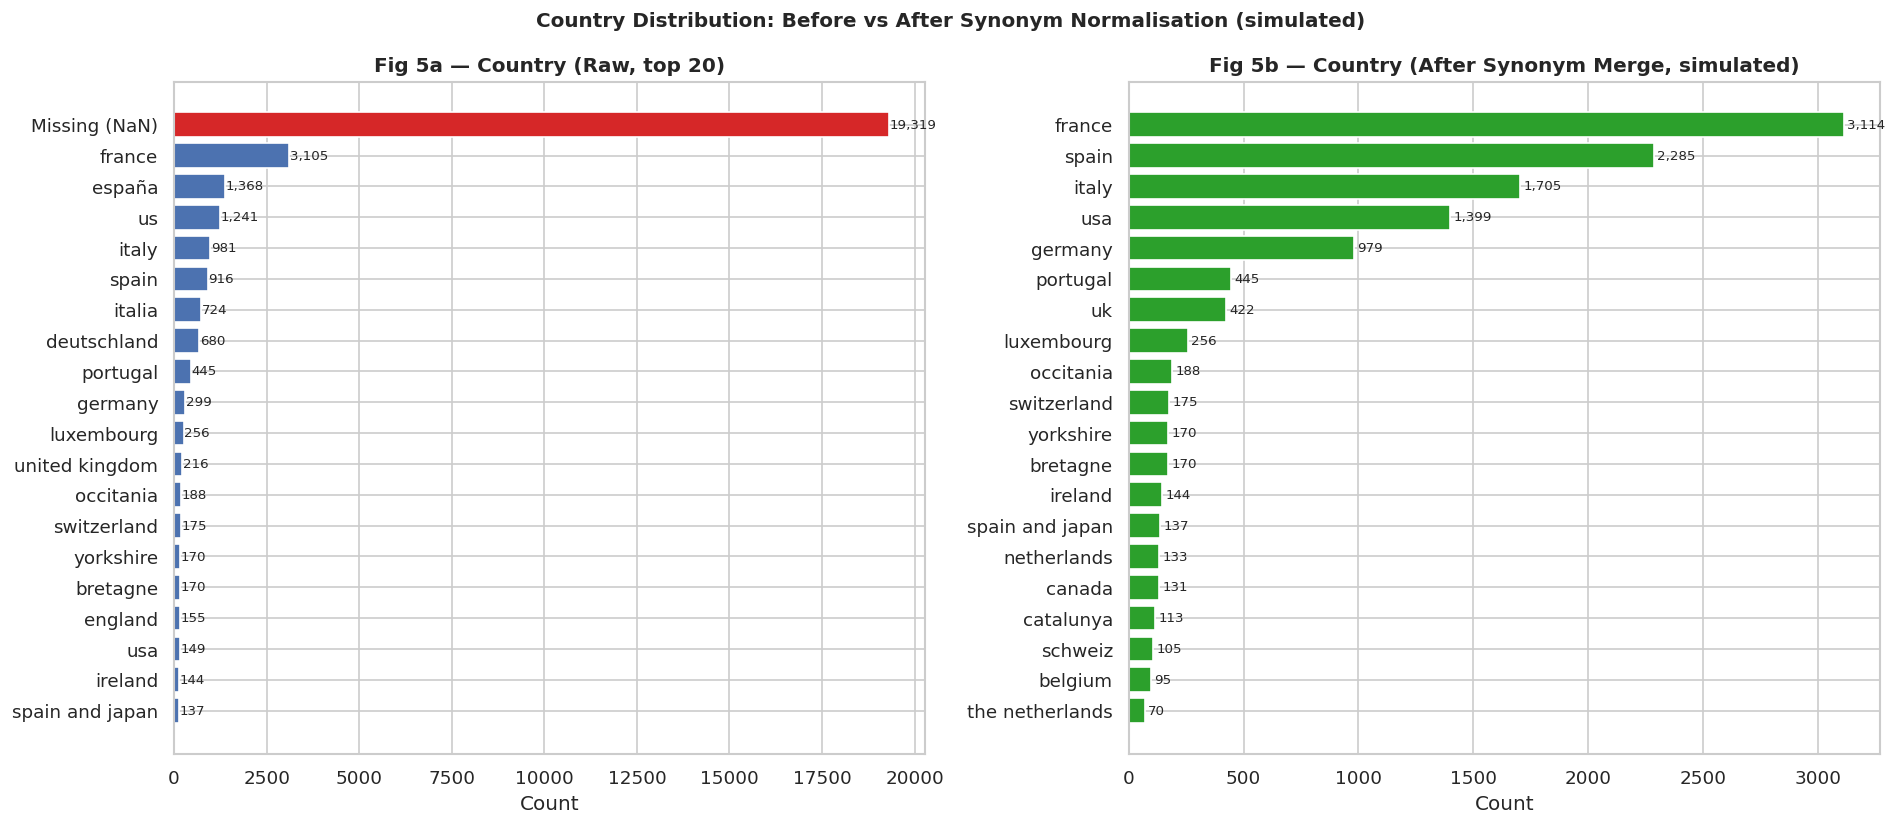


Finding: Country is a free-text folksonomy field, not a standardised country code.
  Multi-language synonyms (españa/spain, italia/italy) fragment country counts.
  Mixed granularity (england, yorkshire, occitania) blurs country vs region boundaries.

Risk: Any group-by-country analysis on raw values understates dominant countries by ~20–40%.
  Cleaning strategy: lowercase → strip → synonym map → region-to-country mapping.


In [48]:
# --- 5.1 Country — Dirty Text Geographic Field ---

print('=== 5.1 Country: Raw Distribution ===')
print(f'Unique values (excl. NaN): {df["Country"].nunique()}')
print(f'Missing: {df["Country"].isna().sum():,} ({df["Country"].isna().mean()*100:.1f}%)')
print()

country_raw = df['Country'].value_counts(dropna=False).head(25)
country_raw.index = country_raw.index.fillna('Missing (NaN)')
print('Top 25 raw values:')
print(country_raw.to_string())

# Synonym analysis
print()
print('=== 5.2 Country: Label Quality Issues (synonym detection) ===')
country_lower = df['Country'].dropna().str.lower().str.strip()
synonym_groups = [
    ('Spain',   ['spain', 'españa', 'espana']),
    ('Italy',   ['italy', 'italia']),
    ('USA',     ['us', 'usa', 'united states', 'united states of america']),
    ('UK',      ['uk', 'united kingdom', 'england', 'great britain']),
    ('Germany', ['germany', 'deutschland']),
    ('France',  ['france', 'frankrijk']),
    ('Portugal',['portugal', 'portogallo']),
]
sim_rows = []
for canonical, variants in synonym_groups:
    counts = {v: (country_lower == v).sum() for v in variants if (country_lower == v).sum() > 0}
    if counts:
        total = sum(counts.values())
        largest = max(counts, key=counts.get)
        sim_rows.append({'Canonical': canonical,
                         'Variants found': ', '.join([f"{k}={v}" for k,v in counts.items()]),
                         'Combined count': total,
                         'Largest variant': largest})
        print(f'  {canonical}: {counts} → combined would be {total:,}')

# Simulate top-10 BEFORE vs AFTER normalisation
print()
print('=== 5.3 Simulated Effect of Synonym Normalisation (Top 10 comparison) ===')
country_norm = country_lower.copy()
merge_map = {}
for canonical, variants in synonym_groups:
    for v in variants:
        merge_map[v] = canonical.lower()
country_norm = country_norm.map(lambda x: merge_map.get(x, x))

top10_before = country_lower.value_counts().head(10)
top10_after  = country_norm.value_counts().head(10)

compare_df = pd.DataFrame({'Before': top10_before, 'After (simulated)': top10_after}).fillna(0).astype(int)
print(compare_df.to_string())
print()
print('Note: This simulation is for diagnostic purposes only (Step 2 = identify, not clean).')
print('It demonstrates that synonym fragmentation artificially splits country rankings.')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Before normalisation
top20_raw = df['Country'].value_counts(dropna=False).head(20)
top20_raw.index = top20_raw.index.fillna('Missing (NaN)')
c_raw = ['#d62728' if idx == 'Missing (NaN)' else '#4c72b0' for idx in top20_raw.index]
axes[0].barh(top20_raw.index, top20_raw.values, color=c_raw, edgecolor='white')
axes[0].invert_yaxis()
axes[0].set_title('Fig 5a — Country (Raw, top 20)', fontweight='bold')
axes[0].set_xlabel('Count')
for bar, v in zip(axes[0].patches, top20_raw.values):
    axes[0].text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=8)

# After simulated normalisation
top20_norm = country_norm.value_counts().head(20)
axes[1].barh(top20_norm.index, top20_norm.values, color='#2ca02c', edgecolor='white')
axes[1].invert_yaxis()
axes[1].set_title('Fig 5b — Country (After Synonym Merge, simulated)', fontweight='bold')
axes[1].set_xlabel('Count')
for bar, v in zip(axes[1].patches, top20_norm.values):
    axes[1].text(bar.get_width() + 15, bar.get_y() + bar.get_height()/2,
                 f'{v:,}', va='center', fontsize=8)

plt.suptitle('Country Distribution: Before vs After Synonym Normalisation (simulated)',
             fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_07_country.png', bbox_inches='tight')
plt.show()

print()
print('Finding: Country is a free-text folksonomy field, not a standardised country code.')
print('  Multi-language synonyms (españa/spain, italia/italy) fragment country counts.')
print('  Mixed granularity (england, yorkshire, occitania) blurs country vs region boundaries.')
print()
print('Risk: Any group-by-country analysis on raw values understates dominant countries by ~20–40%.')
print('  Cleaning strategy: lowercase → strip → synonym map → region-to-country mapping.')

Unique cities (excl. NaN): 689
Missing: 16,767 (51.8%)


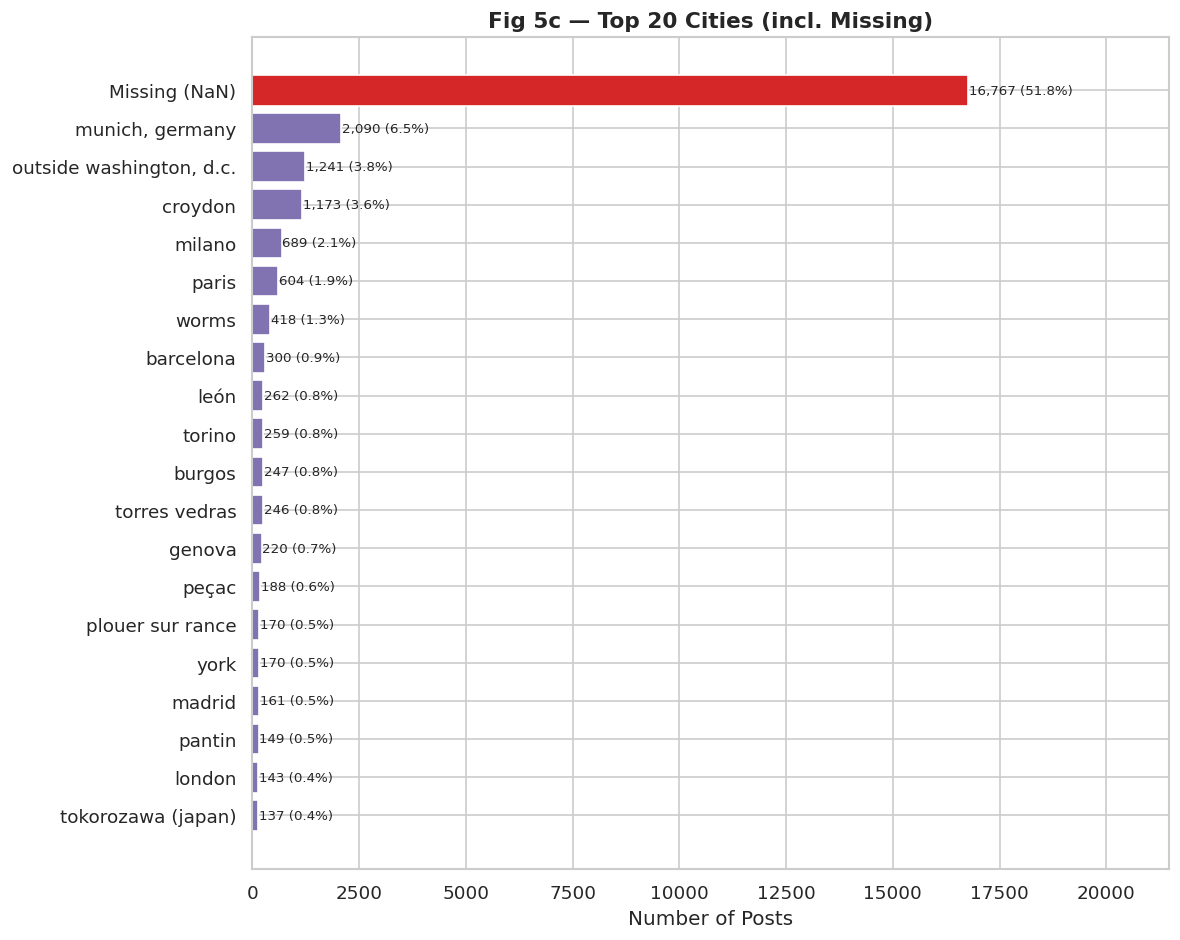


Finding: Top non-missing cities are major international tourist hubs — urban bias confirmed.
  City missingness (51.8%) is even higher than Country, suggesting city-level geotagging
  is an extra voluntary step that most uploaders skip.


In [49]:
# --- 5.2 City Distribution ---

city_vc = df['City'].value_counts(dropna=False)
top20_city = city_vc.head(20).copy()
top20_city.index = top20_city.index.fillna('Missing (NaN)')

print(f'Unique cities (excl. NaN): {df["City"].nunique()}')
print(f'Missing: {df["City"].isna().sum():,} ({df["City"].isna().mean()*100:.1f}%)')

fig, ax = plt.subplots(figsize=(10, 8))
c_city = ['#d62728' if idx == 'Missing (NaN)' else '#8172b2' for idx in top20_city.index]
bars = ax.barh(top20_city.index, top20_city.values, color=c_city, edgecolor='white')
ax.invert_yaxis()
total = len(df)
for bar, v in zip(bars, top20_city.values):
    ax.text(bar.get_width() + 20, bar.get_y() + bar.get_height()/2,
            f'{v:,} ({v/total*100:.1f}%)', va='center', fontsize=8)
ax.set_xlabel('Number of Posts')
ax.set_title('Fig 5c — Top 20 Cities (incl. Missing)', fontsize=13, fontweight='bold')
ax.set_xlim(0, top20_city.max() * 1.28)
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_08_city.png', bbox_inches='tight')
plt.show()

print()
print('Finding: Top non-missing cities are major international tourist hubs — urban bias confirmed.')
print('  City missingness (51.8%) is even higher than Country, suggesting city-level geotagging')
print('  is an extra voluntary step that most uploaders skip.')

Posts with tags: 21,947 (67.8%)
Posts without:   10,435 (32.2%)

Tags per post (non-null only):
count    21947.00
mean        11.93
std         10.25
min          1.00
25%          5.00
50%          8.00
75%         18.00
max         74.00
Skewness: 1.458


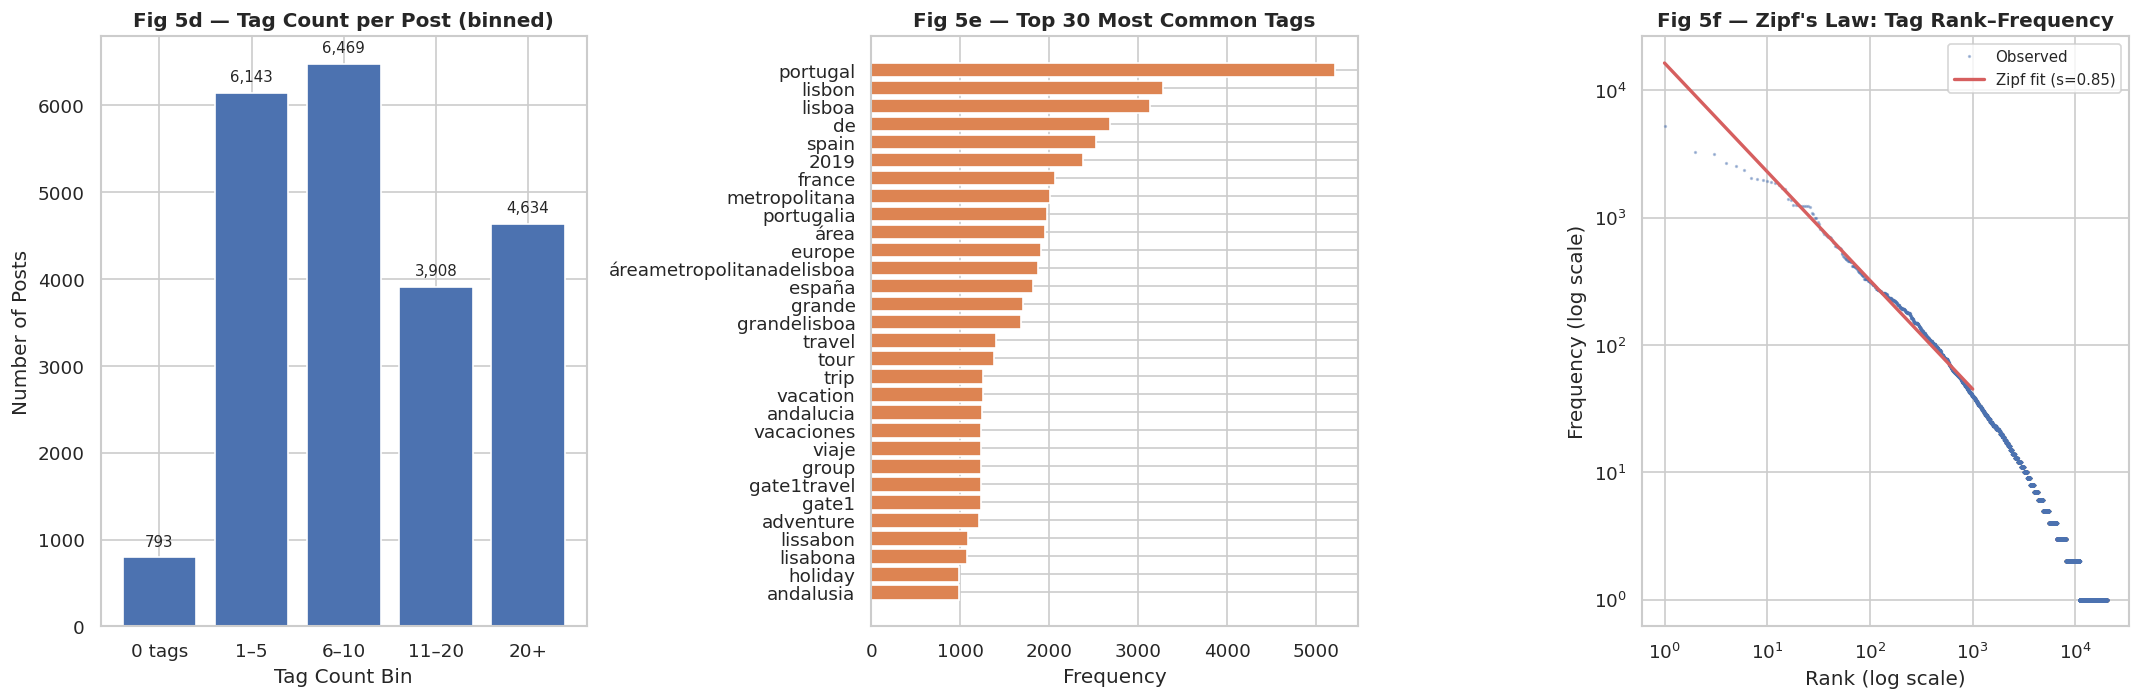


Zipf exponent ≈ 0.854 (close to 1 confirms power-law Folksonomy distribution)
1–5 tag peak: private/casual social behaviour.
10+ tags: marketing accounts or professional photographers maximising discoverability.
Long tail: niche, location-specific, or private tags — rich semantic content but sparse signal.


In [50]:
# --- 5.3 Tags: Folksonomy & Zipf's Law ---

tags_series = df['Tags'].dropna()
print(f'Posts with tags: {len(tags_series):,} ({len(tags_series)/len(df)*100:.1f}%)')
print(f'Posts without:   {df["Tags"].isna().sum():,} ({df["Tags"].isna().mean()*100:.1f}%)')

tag_counts = tags_series.str.split(',').apply(
    lambda x: len([t.strip() for t in x if t.strip()])
)
print(f'\nTags per post (non-null only):')
print(tag_counts.describe().round(2).to_string())
print(f'Skewness: {stats.skew(tag_counts):.3f}')

all_tags = []
for tag_str in tags_series:
    all_tags.extend([t.strip() for t in tag_str.split(',') if t.strip()])
tag_counter = Counter(all_tags)
top_tags = pd.Series(dict(tag_counter.most_common(30)))

# Binned counts
all_tc = tag_counts.reindex(df.index).fillna(0)
bins_t = [0, 1, 5, 10, 20, float('inf')]
labels_t = ['0 tags','1–5','6–10','11–20','20+']
binned = pd.cut(all_tc, bins=bins_t, labels=labels_t, right=True)
bin_vc = binned.value_counts().reindex(labels_t)

# Zipf fit
sorted_freqs = sorted(tag_counter.values(), reverse=True)
ranks = np.arange(1, len(sorted_freqs) + 1)
log_r = np.log(ranks[:1000])
log_f = np.log(sorted_freqs[:1000])
slope, intercept = np.polyfit(log_r, log_f, 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Binned bar chart
axes[0].bar(bin_vc.index, bin_vc.values, color='#4c72b0', edgecolor='white')
axes[0].set_title('Fig 5d — Tag Count per Post (binned)', fontweight='bold')
axes[0].set_xlabel('Tag Count Bin')
axes[0].set_ylabel('Number of Posts')
for bar, v in zip(axes[0].patches, bin_vc.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 100,
                 f'{v:,}', ha='center', va='bottom', fontsize=9)

# Top 30 tags (bar not pie)
axes[1].barh(top_tags.index[::-1], top_tags.values[::-1], color='#dd8452', edgecolor='white')
axes[1].set_title('Fig 5e — Top 30 Most Common Tags', fontweight='bold')
axes[1].set_xlabel('Frequency')

# Zipf log-log
axes[2].loglog(ranks, sorted_freqs, '.', markersize=2, color='#4c72b0', alpha=0.4, label='Observed')
axes[2].loglog(ranks[:1000], np.exp(intercept)*ranks[:1000]**slope,
               'r-', linewidth=2, label=f"Zipf fit (s={-slope:.2f})")
axes[2].set_title("Fig 5f — Zipf's Law: Tag Rank–Frequency", fontweight='bold')
axes[2].set_xlabel('Rank (log scale)')
axes[2].set_ylabel('Frequency (log scale)')
axes[2].legend(fontsize=9)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_09_tags.png', bbox_inches='tight')
plt.show()

print(f'\nZipf exponent ≈ {-slope:.3f} (close to 1 confirms power-law Folksonomy distribution)')
print('1–5 tag peak: private/casual social behaviour.')
print('10+ tags: marketing accounts or professional photographers maximising discoverability.')
print('Long tail: niche, location-specific, or private tags — rich semantic content but sparse signal.')

=== Title Length ===
count    31158.00
mean        24.08
std         21.67
min          1.00
25%          8.00
50%         19.00
75%         32.00
max        251.00
Skewness: 2.425   Kurtosis: 8.936
P90: 49  P99: 109  Max: 251
Empty (len=0): 0

=== Description Length ===
count    14461.00
mean       147.45
std        430.34
min          1.00
25%         23.00
50%         32.00
75%         80.00
max      16463.00
Skewness: 11.295   Kurtosis: 265.692
P90: 321  P99: 1902  Max: 16463
Empty (len=0): 0

Camera-default title pattern (DSCxxxxx, IMGxxxxx): 1,624 (5.21%)


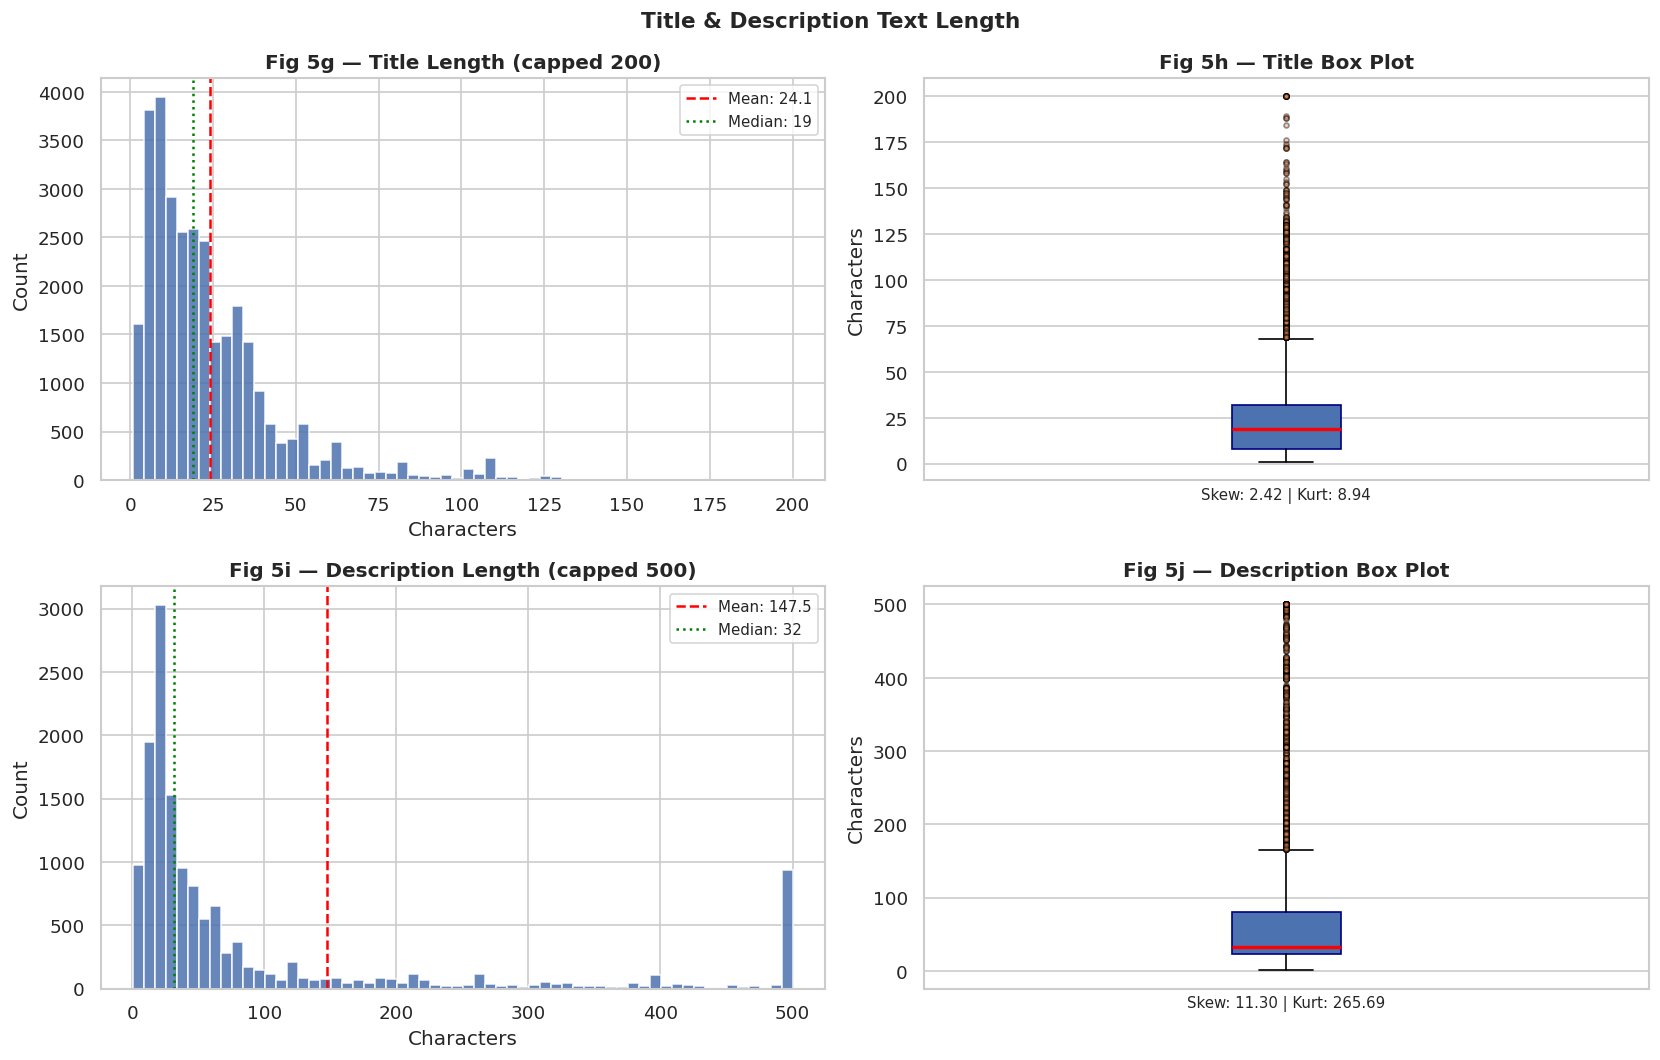

Finding: Both distributions are strongly right-skewed with high kurtosis.
  Most titles are concise (median ~19 chars); descriptions are sparse (median ~32 chars)
  with a long upper tail of detailed posts.

Feature engineering note: Apply log(len+1) transform or winsorize at P99 before ML use.
  (log transform is standard practice for skewed count/length features; not taught in wk5/6
   but is a well-justified choice — cite applied ML references in report.)


In [51]:
# --- 5.4 Title & Description Length ---

title_len = df['Title'].dropna().str.len()
desc_len  = df['Description'].dropna().str.len()

# Default camera-filename titles (e.g., "DSC01234", "IMG_5678", "DCIM0001")
camera_pattern = r'^(dsc|img|dcim|p\d{7}|\d{8})[_-]?\d{0,6}$'
title_is_camera = df['Title'].dropna().str.lower().str.strip().str.match(camera_pattern)

for name, series in [('Title', title_len), ('Description', desc_len)]:
    print(f'=== {name} Length ===')
    print(series.describe().round(2).to_string())
    print(f'Skewness: {stats.skew(series):.3f}   Kurtosis: {stats.kurtosis(series):.3f}')
    print(f'P90: {series.quantile(0.90):.0f}  P99: {series.quantile(0.99):.0f}  Max: {series.max()}')
    print(f'Empty (len=0): {(series == 0).sum():,}')
    print()

print(f'Camera-default title pattern (DSCxxxxx, IMGxxxxx): {title_is_camera.sum():,} ({title_is_camera.mean()*100:.2f}%)')

fig, axes = plt.subplots(2, 2, figsize=(14, 9))

for i, (name, series, cap) in enumerate([('Title', title_len, 200), ('Description', desc_len, 500)]):
    data_c = series.clip(upper=cap)

    axes[i][0].hist(data_c, bins=60, color='#4c72b0', edgecolor='white', alpha=0.85)
    axes[i][0].axvline(series.mean(), color='red', linestyle='--', lw=1.5,
                        label=f'Mean: {series.mean():.1f}')
    axes[i][0].axvline(series.median(), color='green', linestyle=':', lw=1.5,
                        label=f'Median: {series.median():.0f}')
    axes[i][0].set_title(f'Fig 5{["g","i"][i]} — {name} Length (capped {cap})', fontweight='bold')
    axes[i][0].set_xlabel('Characters')
    axes[i][0].set_ylabel('Count')
    axes[i][0].legend(fontsize=9)

    axes[i][1].boxplot(data_c, vert=True, patch_artist=True,
                        boxprops=dict(facecolor='#4c72b0', color='navy'),
                        medianprops=dict(color='red', lw=2),
                        flierprops=dict(marker='o', markerfacecolor='#dd8452', ms=3, alpha=0.4))
    axes[i][1].set_title(f'Fig 5{["h","j"][i]} — {name} Box Plot', fontweight='bold')
    axes[i][1].set_ylabel('Characters')
    axes[i][1].set_xticks([])
    axes[i][1].set_xlabel(
        f'Skew: {stats.skew(series):.2f} | Kurt: {stats.kurtosis(series):.2f}', fontsize=9)

plt.suptitle('Title & Description Text Length', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_10_text_length.png', bbox_inches='tight')
plt.show()

print('Finding: Both distributions are strongly right-skewed with high kurtosis.')
print('  Most titles are concise (median ~19 chars); descriptions are sparse (median ~32 chars)')
print('  with a long upper tail of detailed posts.')
print()
print('Feature engineering note: Apply log(len+1) transform or winsorize at P99 before ML use.')
print('  (log transform is standard practice for skewed count/length features; not taught in wk5/6')
print('   but is a well-justified choice — cite applied ML references in report.)')

Unique users: 2,273
count    2273.00
mean       14.25
std        89.18
min         1.00
25%         1.00
50%         2.00
75%         6.00
max      2360.00
Users with 1 post: 878 (38.6%)
Top 1% (23) → 43.8% of posts


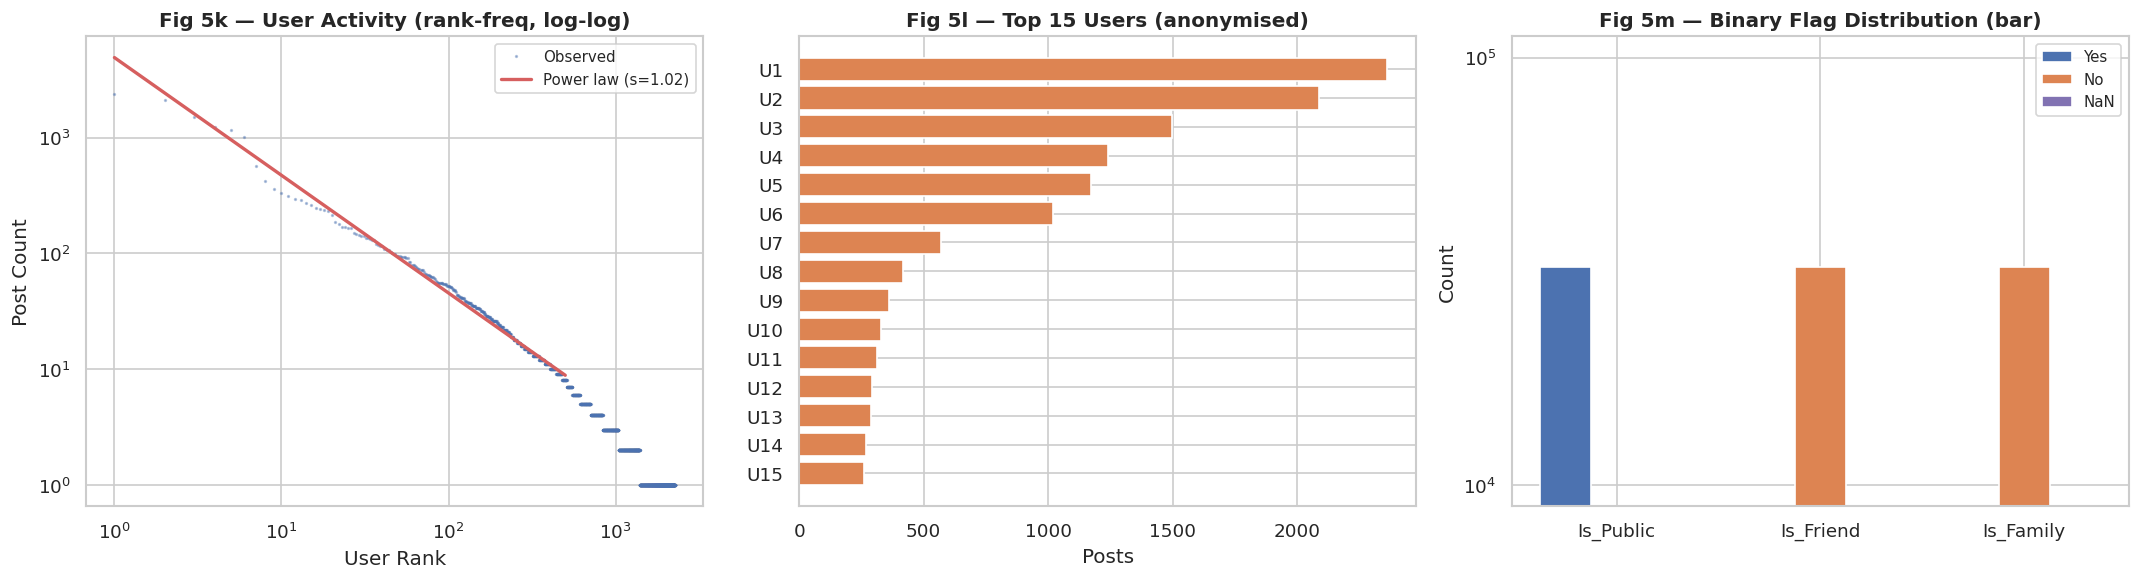


Power law exponent ≈ 1.016
Is_Public is ~100% Yes — survivor bias (public API only returns public records).
Is_Friend and Is_Family are near-zero constants.
All three flag columns should be excluded from downstream ML features.


In [52]:
# --- 5.5 User Activity Distribution & Binary Flags ---

user_posts = df['User_ID'].value_counts()
n_users = len(user_posts)
top1pct = int(n_users * 0.01) + 1

print(f'Unique users: {n_users:,}')
print(user_posts.describe().round(2).to_string())
print(f'Users with 1 post: {(user_posts==1).sum():,} ({(user_posts==1).mean()*100:.1f}%)')
print(f'Top 1% ({top1pct}) → {user_posts.head(top1pct).sum()/len(df)*100:.1f}% of posts')

sorted_uf = np.sort(user_posts.values)[::-1]
ur = np.arange(1, len(sorted_uf)+1)
log_ur = np.log(ur[:500]); log_uf = np.log(sorted_uf[:500])
u_slope, u_intercept = np.polyfit(log_ur, log_uf, 1)

# Is_Public, Is_Friend, Is_Family — stacked bar instead of pie
flag_cols = ['Is_Public', 'Is_Friend', 'Is_Family']
flag_data = {}
for col in flag_cols:
    vc = df[col].value_counts(dropna=False).sort_index()
    flag_data[col] = {('NaN' if pd.isna(k) else ('Yes' if k==1.0 else 'No')): v for k,v in vc.items()}

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# User activity log-log power law
axes[0].loglog(ur, sorted_uf, '.', ms=2, color='#4c72b0', alpha=0.4, label='Observed')
axes[0].loglog(ur[:500], np.exp(u_intercept)*ur[:500]**u_slope,
               'r-', lw=2, label=f'Power law (s={-u_slope:.2f})')
axes[0].set_title('Fig 5k — User Activity (rank-freq, log-log)', fontweight='bold')
axes[0].set_xlabel('User Rank')
axes[0].set_ylabel('Post Count')
axes[0].legend(fontsize=9)

# Top 15 users (bar)
top15 = user_posts.head(15)
anon = [f'U{i+1}' for i in range(15)]
axes[1].barh(anon[::-1], top15.values[::-1], color='#dd8452', edgecolor='white')
axes[1].set_title('Fig 5l — Top 15 Users (anonymised)', fontweight='bold')
axes[1].set_xlabel('Posts')

# Binary flags — grouped bar (not pie)
flag_labels = ['Yes', 'No', 'NaN']
x = np.arange(len(flag_cols))
w = 0.25
colors_f = {'Yes':'#4c72b0', 'No':'#dd8452', 'NaN':'#8172b2'}
for j, lbl in enumerate(flag_labels):
    vals = [flag_data[col].get(lbl, 0) for col in flag_cols]
    axes[2].bar(x + j*w, vals, w, label=lbl, color=colors_f[lbl], edgecolor='white')
axes[2].set_title('Fig 5m — Binary Flag Distribution (bar)', fontweight='bold')
axes[2].set_xticks(x + w)
axes[2].set_xticklabels(flag_cols)
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)
axes[2].set_yscale('log')  # log scale because Yes >> No/NaN

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_11_user_flags.png', bbox_inches='tight')
plt.show()

print(f'\nPower law exponent ≈ {-u_slope:.3f}')
print('Is_Public is ~100% Yes — survivor bias (public API only returns public records).')
print('Is_Friend and Is_Family are near-zero constants.')
print('All three flag columns should be excluded from downstream ML features.')

---
## Section  — Numeric Statistics Summary (Skewness, Kurtosis, IQR) & Modelling Implications

=== Numeric Variables — Descriptive Statistics Summary ===
                   Mean        Median           Std           IQR  Skewness  Kurtosis  IQR Outliers  Outlier %
Column                                                                                                        
Post_ID    4.955396e+10  4.932141e+10  1.287015e+09  2.513068e+08   -23.339   748.381          5151      15.91
Server     6.535787e+04  6.553500e+04  3.393900e+03  0.000000e+00   -19.114   363.450            88       0.27
Farm       6.582000e+01  6.600000e+01  3.420000e+00  0.000000e+00   -19.116   363.579            88       0.27
Latitude   4.287000e+01  4.315000e+01  4.170000e+00  7.500000e+00    -0.029    -1.343             0       0.00
Longitude  3.500000e-01  2.080000e+00  6.470000e+00  1.156000e+01    -0.109    -1.436             0       0.00


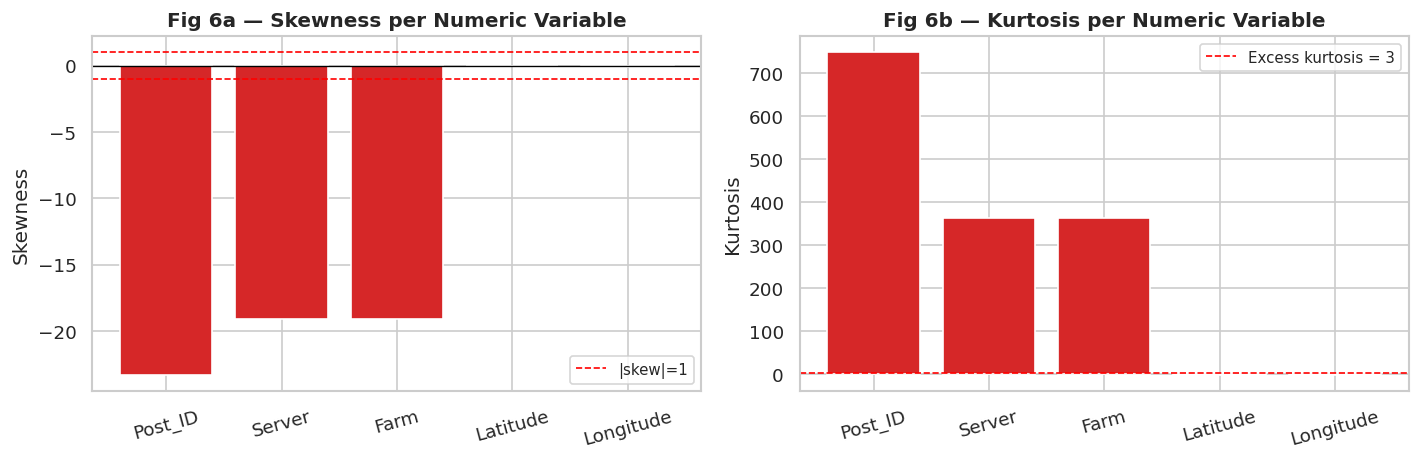

In [53]:
num_cols = ['Post_ID', 'Server', 'Farm', 'Latitude', 'Longitude']

rows = []
for col in num_cols:
    s = df[col].dropna()
    q1, q3 = s.quantile(0.25), s.quantile(0.75)
    iqr = q3 - q1
    n_out = ((s < q1-1.5*iqr) | (s > q3+1.5*iqr)).sum()
    rows.append({'Column': col,
                 'Mean': round(s.mean(),2), 'Median': round(s.median(),2),
                 'Std': round(s.std(),2), 'IQR': round(iqr,2),
                 'Skewness': round(stats.skew(s),3),
                 'Kurtosis': round(stats.kurtosis(s),3),
                 'IQR Outliers': int(n_out),
                 'Outlier %': round(n_out/len(s)*100,2)})

stats_df = pd.DataFrame(rows).set_index('Column')
print('=== Numeric Variables — Descriptive Statistics Summary ===')
print(stats_df.to_string())

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

c_skew = ['#d62728' if abs(v) > 1 else '#4c72b0' for v in stats_df['Skewness']]
axes[0].bar(stats_df.index, stats_df['Skewness'], color=c_skew, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axhline(1, color='red', ls='--', lw=1, label='|skew|=1')
axes[0].axhline(-1, color='red', ls='--', lw=1)
axes[0].set_title('Fig 6a — Skewness per Numeric Variable', fontweight='bold')
axes[0].set_ylabel('Skewness')
axes[0].legend(fontsize=9)
axes[0].tick_params(axis='x', rotation=15)

c_kurt = ['#d62728' if v > 3 else '#4c72b0' for v in stats_df['Kurtosis']]
axes[1].bar(stats_df.index, stats_df['Kurtosis'], color=c_kurt, edgecolor='white')
axes[1].axhline(3, color='red', ls='--', lw=1, label='Excess kurtosis = 3')
axes[1].set_title('Fig 6b — Kurtosis per Numeric Variable', fontweight='bold')
axes[1].set_ylabel('Kurtosis')
axes[1].legend(fontsize=9)
axes[1].tick_params(axis='x', rotation=15)

plt.tight_layout()
plt.savefig(SAVE_DIR + 'fig_12_skew_kurt.png', bbox_inches='tight')
plt.show()

In [54]:
print('=' * 80)
print('SECTION 6 — SUMMARY & MODELLING IMPLICATIONS')
print('=' * 80)
print()

implications = [
    ('KEEP — strong signal',
     ['Latitude/Longitude: 0% missing, geographic clustering potential (excl. Null Island)',
      'Post_Date: complete, supports temporal trend / seasonal analysis',
      'Upload Lag (derived): discriminates casual vs archive users',
      'Tag count (derived): correlates with user engagement style',
      'Title/Desc length (derived): content quality proxy — log-transform before use']),

    ('USE WITH CAUTION — quality issues',
     ['Country: free-text, multi-language synonyms, 59.6% missing → needs normalisation + missing-flag',
      'City: 51.8% missing → missing-flag only; direct use will introduce bias',
      'Tags: 32.2% missing → encode as has_tags binary + tag_count numeric',
      'Taken_Date: 1970 epoch errors → filter before temporal modelling']),

    ('EXCLUDE or TRANSFORM',
     ['Is_Public / Is_Friend / Is_Family: near-zero variance constants — drop from features',
      'Farm / Server: infrastructure identifiers, not user signals — drop from ML features',
      'Secret: hash token, no predictive value for content analysis',
      'Post_ID: primary key, not a predictive feature']),
]

for category, items in implications:
    print(f'[{category}]')
    for item in items:
        print(f'  • {item}')
    print()

print('Next: bivariate analysis (Section 2 of Step 2) to explore variable relationships.')

SECTION 6 — SUMMARY & MODELLING IMPLICATIONS

[KEEP — strong signal]
  • Latitude/Longitude: 0% missing, geographic clustering potential (excl. Null Island)
  • Post_Date: complete, supports temporal trend / seasonal analysis
  • Upload Lag (derived): discriminates casual vs archive users
  • Tag count (derived): correlates with user engagement style
  • Title/Desc length (derived): content quality proxy — log-transform before use

[USE WITH CAUTION — quality issues]
  • Country: free-text, multi-language synonyms, 59.6% missing → needs normalisation + missing-flag
  • City: 51.8% missing → missing-flag only; direct use will introduce bias
  • Tags: 32.2% missing → encode as has_tags binary + tag_count numeric
  • Taken_Date: 1970 epoch errors → filter before temporal modelling

[EXCLUDE or TRANSFORM]
  • Is_Public / Is_Friend / Is_Family: near-zero variance constants — drop from features
  • Farm / Server: infrastructure identifiers, not user signals — drop from ML features
  • Secret

# Step : Bivariate Analysis

This section explores how pairs of variables relate to each other, with the aim of identifying patterns, trends, and potential inconsistencies in the dataset.

The analysis is organised into five parts, each focusing on a different relationship:

1. The relationship between tag usage (`tag_count`) and title length (`title_length`).
2. The relationship between tag usage (`tag_count`) and description length (`description_length`).
3. The temporal distribution of posting activity within France (date & country).
4. The dominant posting country across years with high activity levels (date & country).
5. The spatial distribution of photo locations using latitude (`Latitude`) and longitude (`Longitude`).

Different visualisation methods are used depending on the nature of the variables.  
Scatter plots with regression lines are used to explore relationships between numeric variables, while bar charts are used for temporal and categorical comparisons.  
For spatial analysis, a heatmap is used to highlight geographic density and clustering patterns.

Each part follows a consistent structure: **Purpose → Method → Finding → Risk**, ensuring that the analysis is clear, well-structured, and easy to interpret, while also acknowledging any limitations or potential biases in the data.

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

SAVE_DIR = './'
dataset_path = f'flickr_dataset.csv'

df = pd.read_csv(dataset_path)
date_cols = ['Post_Date', 'Taken_Date', 'Min_Taken_Date']

for col in date_cols:
    df[col] = pd.to_datetime(df[col], errors='coerce')

print('NaT rates after datetime parsing:')
for col in date_cols:
    n = df[col].isna().sum()
    print(f'  {col}: {n:,} ({n/len(df)*100:.2f}%)')

print(f'\nDataset loaded: {df.shape[0]:,} rows × {df.shape[1]} columns')

NaT rates after datetime parsing:
  Post_Date: 0 (0.00%)
  Taken_Date: 0 (0.00%)
  Min_Taken_Date: 0 (0.00%)

Dataset loaded: 32,382 rows × 18 columns


---
## Section 1 — Tag Usage vs Title Length

**Purpose:**  
This part focuses on exploring the relationship between tag usage and title length. The aim is to see whether posts with more tags also tend to have longer titles, so as to evaluate whether effort in tagging and title writing is correlated.

**Method:**  
Two derived variables are created based on the original tag and title fields. tag_count represents the number of tags in each post, calculated by splitting the Tags field using commas. title_length represents the length of the title, measured by counting the number of characters.

During preprocessing, extreme values are removed to avoid distorting the overall pattern. Posts with tag_count > 50 and title_length > 150 are excluded, allowing the analysis to focus on typical user behaviour.

For the analysis, a scatter plot combined with a regression line (using seaborn’s regplot) is used to show both the distribution and the overall trend. The scatter points are displayed with reduced opacity (alpha = 0.3) to minimise visual overlap, while the red regression line captures the general linear relationship between tag count and title length.

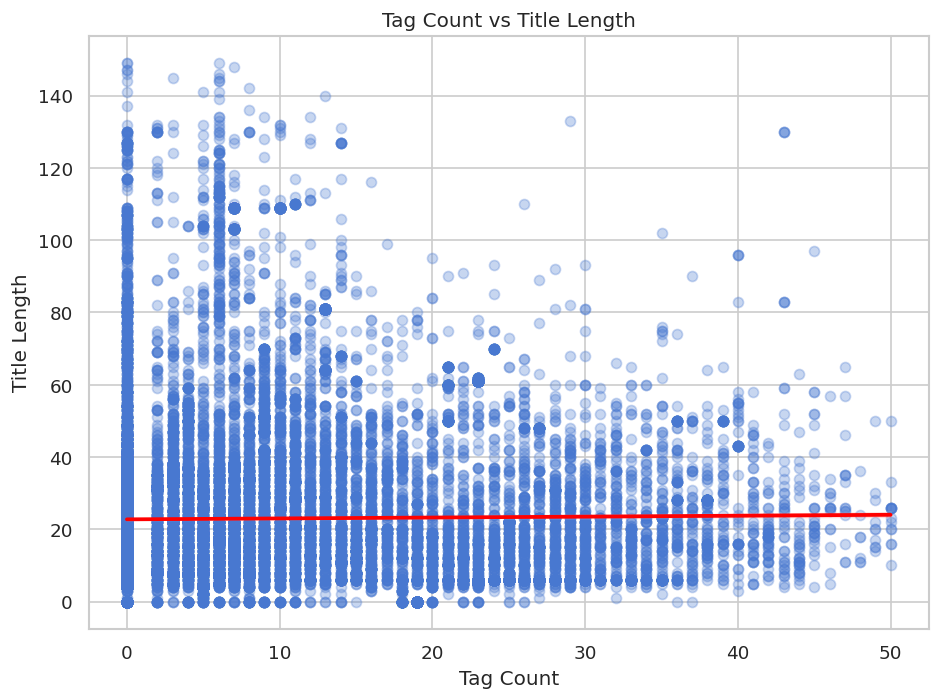

In [56]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === 1. Create derived variables ===
# tag_count: number of tags per post (split by comma)
df['tag_count'] = df['Tags'].apply(
    lambda x: len(str(x).split(',')) if pd.notnull(x) else 0
)

# title_length: number of characters in the title
df['title_length'] = df['Title'].apply(
    lambda x: len(str(x)) if pd.notnull(x) else 0
)

# === 2. Data cleaning ===
# Remove extreme values to improve visualization clarity
df_clean = df[(df['tag_count'] <= 50) & (df['title_length'] <= 150)]

# === 3. Plot ===
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,   # no sampling, use full dataset
    x='tag_count',
    y='title_length',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title('Tag Count vs Title Length')
plt.xlabel('Tag Count')
plt.ylabel('Title Length')

plt.tight_layout()
plt.savefig('fig_13_tag_vs_title.png')
plt.show()

### Finding
From the plot, it’s pretty clear that tag usage and title length don’t really have a strong relationship.  
Even though the trend line goes slightly upward, the points are very spread out, which means having more tags doesn’t necessarily lead to longer titles.  
There are also a lot of posts with zero tags, but their title lengths still vary quite a bit, suggesting that tagging and title writing are mostly independent behaviours.

### Risk
A large number of posts with zero tags creates a dense vertical cluster, which can dominate the visual pattern and make it harder to notice any subtle trends.  
The data is also quite skewed, with most posts having only a few tags and short titles, along with a small number of extreme cases that may affect interpretation.  
Finally, title length is only a rough indicator and doesn’t really tell us much about the actual quality of the content.

---
## Section 2 — Tag Usage vs Description Length

**Purpose:**  
This part focuses on exploring the relationship between tag usage and description length. The aim is to examine whether posts with more tags also tend to have longer descriptions, so as to evaluate whether effort in tagging and content writing is correlated.

**Method:**  
Two derived variables are created based on the original tag and description fields. tag_count represents the number of tags in each post, calculated by splitting the Tags field using commas. description_length represents the length of the description, measured by counting the number of characters.

During preprocessing, extreme values are removed to avoid distorting the overall pattern. Posts with tag_count > 50 and description_length > 1000 are excluded, allowing the analysis to focus on typical user behaviour.

For the analysis, a scatter plot combined with a regression line (using seaborn’s regplot) is used to show both the distribution and the overall trend. The scatter points are displayed with reduced opacity (alpha = 0.3) to minimise visual overlap, while the red regression line captures the general linear relationship between tag count and description length.

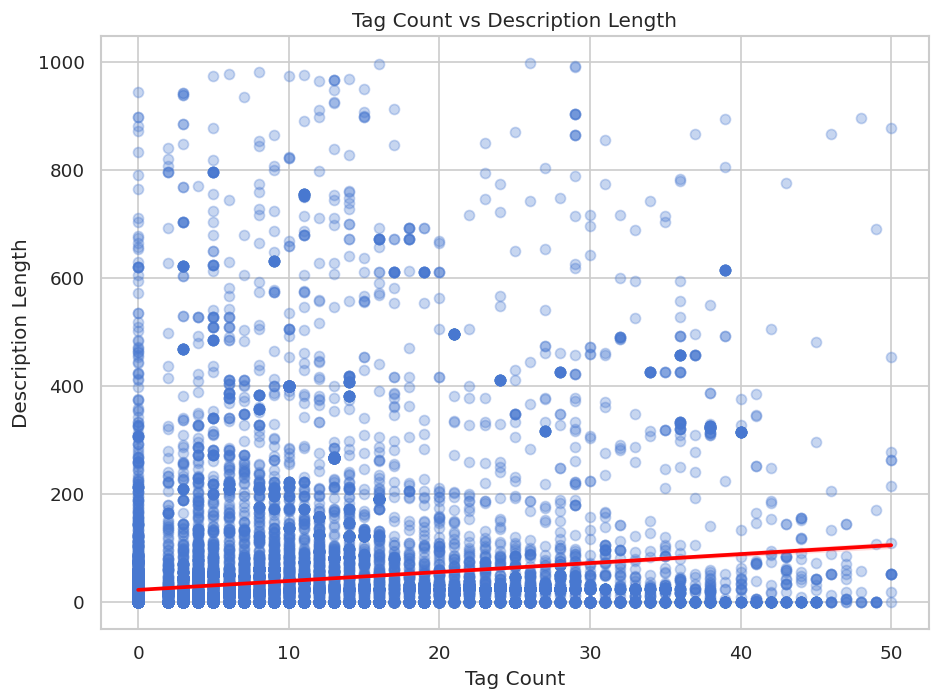

In [57]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# === 1. Create derived variable ===
# description_length: number of characters in the description
df['description_length'] = df['Description'].apply(
    lambda x: len(str(x)) if pd.notnull(x) else 0
)

# === 2. Data cleaning ===
# Remove extreme values to improve visualization clarity
df_clean = df[(df['tag_count'] <= 50) & (df['description_length'] <= 1000)]

# === 3. Plot ===
plt.figure(figsize=(8,6))

sns.regplot(
    data=df_clean,   # use full dataset without sampling
    x='tag_count',
    y='description_length',
    scatter_kws={'alpha':0.3},
    line_kws={'color':'red'}
)

plt.title('Tag Count vs Description Length')
plt.xlabel('Tag Count')
plt.ylabel('Description Length')

plt.tight_layout()
plt.savefig('fig_14_tag_vs_description.png')
plt.show()

### Finding
From the plot, tag count and description length don’t seem to have a strong relationship.  
The trend line goes slightly upward, which suggests that posts with more tags might have slightly longer descriptions, but the effect is very small.  
The points are quite spread out, so the relationship is not very consistent.  
There is also a clear cluster near zero, showing that many posts have little or no description regardless of how many tags they use.  
At the same time, a few posts have very long descriptions, which adds more variation to the data.

### Risk
A large number of posts with very short or zero descriptions creates a dense cluster at the bottom, which can dominate the plot and make small patterns harder to see.  
The data is also quite skewed, with most posts having few tags and short descriptions, along with a few extreme cases that can affect interpretation.  
Using the full dataset can make the plot crowded (overplotting), which reduces clarity.  
Finally, description length is only a rough indicator and doesn’t necessarily reflect the actual quality of the content.

---
## Section 3 — Temporal Distribution within France

**Purpose:**  
This part focuses on examining the temporal distribution of posting activity within a single country (France).  
The aim is to understand how the number of posts varies across months and to identify whether there are any noticeable seasonal patterns or irregular concentrations in posting behaviour.

**Method:**  
The dataset is first filtered to include only records where the Country is France.  
A new variable, month, is then derived from the Post_Date field to represent the posting month.

The number of posts is aggregated by month to capture the distribution of activity throughout the year.  
A bar chart is used for visualisation, as it provides a clear comparison of posting frequency across discrete time categories (months), making it easier to identify peaks, gaps, or uneven patterns in the data.

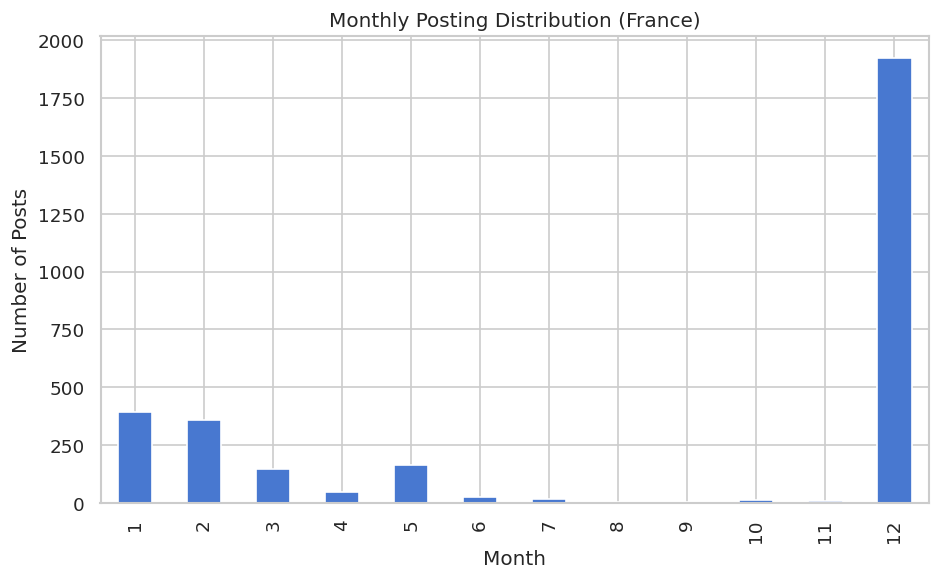

In [58]:
# Filter dataset to include only posts from France
df_fr = df[df['Country'] == 'france'].copy()

# Extract month from Post_Date for temporal analysis
df_fr['month'] = df_fr['Post_Date'].dt.month

# Count number of posts per month
monthly_counts = df_fr['month'].value_counts().sort_index()

# Plot monthly distribution using bar chart
# Bar chart is suitable for comparing categorical (month) counts
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))

monthly_counts.plot(kind='bar')

# Add labels and title for clarity
plt.title('Monthly Posting Distribution (France)')
plt.xlabel('Month')
plt.ylabel('Number of Posts')

# Adjust layout and save figure
plt.tight_layout()
plt.savefig('fig_france_month.png')

# Display the plot
plt.show()

### Finding
From the chart, posting activity in France is very uneven across different months.  
December stands out with a much higher number of posts compared to the rest of the year.  
Most other months have relatively low activity, with only a few months like January and February showing moderate levels.  
However, this strong peak in December is likely caused by the data being concentrated in that month, rather than reflecting real seasonal behaviour.

### Risk
The heavy concentration of posts in December suggests there may be a data collection bias, which could distort the overall pattern.  
Because most of the data is clustered in a single month, it becomes difficult to draw reliable conclusions about seasonal trends.  
In addition, this analysis only focuses on France, so the findings may not represent the full dataset.  
There may also be inconsistencies or missing values in the Country field, which could affect the accuracy of the filtered data.

---
## Section 4 — Top Country by Post Count across High-Activity Years

**Purpose:**  
This part focuses on examining how the dominant posting country changes across years with relatively high posting activity.  
The aim is to identify which country contributed the most posts in each active year and to observe whether the leading country remains consistent over time.

**Method:**  
A new variable, year, is first derived from the Post_Date field to represent the posting year.  
The Country field is then cleaned by converting values to lowercase, trimming extra spaces, and standardising a small number of common variants such as *italia → italy* and *usa / united states → us*.

Records with missing or invalid country values are removed before analysis.  
Next, the total number of posts is calculated for each year, and only years with more than 1000 posts are kept in order to focus on years with meaningful posting volume.

Within each selected year, the country with the highest post count is identified.  
The results are then visualised using a bar chart, where bar height represents the number of posts and bar colour indicates the top country for that year.

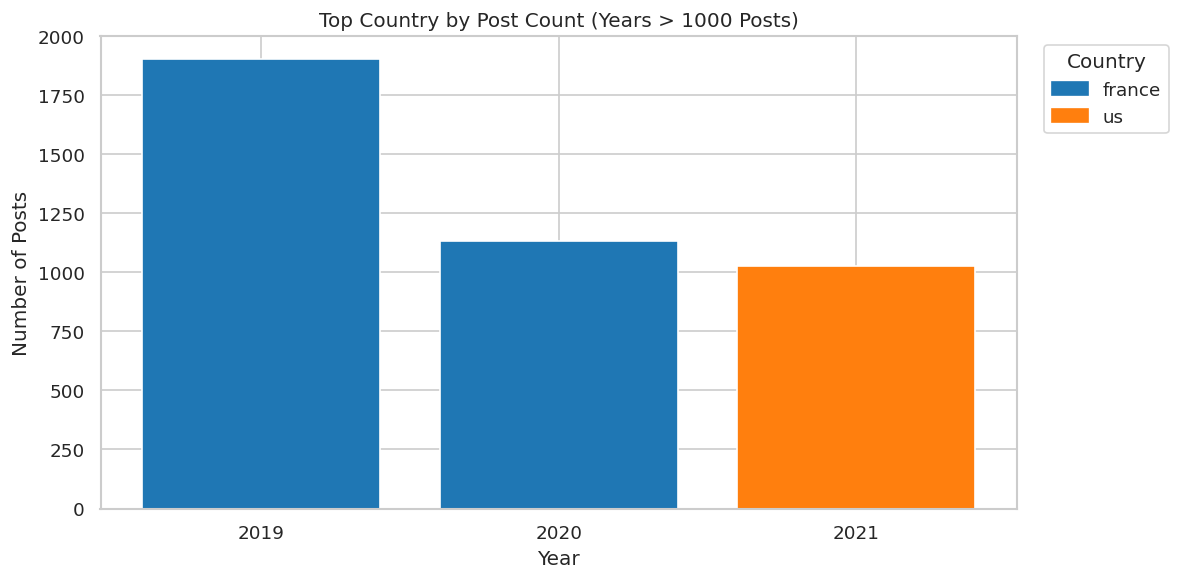

In [59]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# === 1. Extract year from Post_Date ===
df['year'] = df['Post_Date'].dt.year

# === 2. Clean Country field ===
df['Country'] = df['Country'].str.lower().str.strip()

df['Country'] = df['Country'].replace({
    'italia': 'italy',
    'usa': 'us',
    'united states': 'us',
    'uk': 'united kingdom',
    'england': 'united kingdom'
})

# === 3. Keep valid country values only ===
df_clean = df[df['Country'].notna()].copy()
df_clean = df_clean[~df_clean['Country'].str.contains('no country', na=False)]

# === 4. Compute total posts per year ===
year_counts = df_clean.groupby('year').size().reset_index(name='total_posts')

# === 5. Keep only years with more than 1000 posts ===
valid_years = year_counts[year_counts['total_posts'] > 1000]['year']
df_filtered = df_clean[df_clean['year'].isin(valid_years)]

# === 6. Find the top country for each selected year ===
top_country_per_year = (
    df_filtered.groupby(['year', 'Country'])
    .size()
    .reset_index(name='post_count')
    .sort_values(['year', 'post_count'], ascending=[True, False])
    .groupby('year', as_index=False)
    .first()
)

# === 7. Create colour mapping ===
unique_countries = top_country_per_year['Country'].unique()
colours = sns.color_palette('tab10', len(unique_countries))
colour_map = dict(zip(unique_countries, colours))
bar_colours = [colour_map[c] for c in top_country_per_year['Country']]

# === 8. Plot bar chart ===
plt.figure(figsize=(10, 5))

plt.bar(
    top_country_per_year['year'].astype(str),
    top_country_per_year['post_count'],
    color=bar_colours
)

plt.title('Top Country by Post Count (Years > 1000 Posts)')
plt.xlabel('Year')
plt.ylabel('Number of Posts')

# === 9. Add legend ===
handles = [
    plt.Rectangle((0, 0), 1, 1, color=colour_map[c])
    for c in unique_countries
]

plt.legend(
    handles,
    unique_countries,
    title='Country',
    bbox_to_anchor=(1.02, 1),
    loc='upper left'
)

plt.tight_layout()
plt.savefig('fig_top_country_filtered.png')
plt.show()

### Finding
From the chart, France is the top contributing country in 2019 and 2020, with a noticeably higher number of posts in 2019.  
In 2021, the United States becomes the top country, although its post count is slightly lower compared to France in earlier years.  
Overall, the leading country changes over time, but the differences between years are not extremely large except for the peak in 2019.  
This suggests that posting activity is somewhat concentrated in a few countries, with France playing a dominant role in earlier years.

### Risk
The result is based only on the top country in each year, which ignores the contribution of other countries and may oversimplify the overall distribution.  
Differences in post counts across years may be influenced by uneven data coverage rather than real changes in user behaviour.  
In addition, the Country field requires cleaning and standardisation, and any remaining inconsistencies or missing values may affect the accuracy of the results.  
Finally, restricting the analysis to years with more than 1000 posts may exclude potentially relevant trends in smaller years.

---
## Section 5 — Spatial Relationship (Latitude vs Longitude)

**Purpose:**  
Explore the spatial distribution of photo locations to understand how records are geographically distributed across regions.  
This analysis aims to identify clustering patterns, hotspots, and potential spatial bias in the dataset.

**Method:**  
Use Latitude and Longitude coordinates to construct a heatmap that visualises the density of photo locations.  
A density-based visualisation is chosen instead of a simple scatter plot to reduce overplotting and highlight areas with high concentrations of data.  
The heatmap allows for clearer identification of geographic clusters and regional differences in activity.

In [60]:
import folium
from folium.plugins import HeatMap

heat_data = df[['Latitude', 'Longitude']].dropna().values.tolist()

m = folium.Map(
    location=[df['Latitude'].mean(), df['Longitude'].mean()],
    zoom_start=5,
    tiles='CartoDB positron'
)

HeatMap(
    heat_data,
    radius=8,
    blur=12
).add_to(m)

m.save('map_heatmap.html')
m


### Finding
The heatmap reveals clear geographic clustering of photo locations across France, Spain, Portugal, and nearby parts of Western Europe.  
Higher-density hotspots can be seen around several major urban and tourist areas, including Paris, Geneva, Madrid, and Lisbon, indicating that photo activity is concentrated in specific regions rather than evenly distributed.  
The distribution is not uniform, with especially strong concentration in France and parts of the Iberian Peninsula.  
A few low-density points also appear in parts of North Africa, but overall coverage outside the main European region is limited.

### Risk
The spatial distribution shows clear geographic bias, with the dataset heavily concentrated in a limited part of Europe.  
This uneven coverage reduces the generalisability of location-based insights, as many other regions are underrepresented.  
In addition, the heatmap smooths local variation, which may hide smaller-scale spatial differences.  
The reliance on geotagged data also introduces bias, since not all users enable location information.